In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import table
import io
import dataframe_image as dfi
import seaborn as sns

from pathlib import Path

# Define paths
DATA_PATH = Path("../../../../data/raw")

In [4]:
# Load data
df = pd.read_excel(DATA_PATH / "2015_Birth_Final.xlsx")


📊 COMPREHENSIVE STATISTICAL ANALYSIS OF MISSING Birth_Weight(grams) RECORDS
(IUPAC Compliant Output)

📌 DATASET OVERVIEW:
   • Total records with missing Birth_Weight(grams): 33,604
   • Total records with complete Birth_Weight(grams): 302,493

📌 PART 1: UNIVARIATE ANALYSIS - DETAILED STATISTICS FOR EACH VARIABLE

📌 PART 2: CREATING IUPAC COMPLIANT EXCEL REPORT
✅ Created IUPAC compliant Excel report: missing_Birth_Weight(grams)_iupac_stats.xlsx

📌 PART 3: CREATING IUPAC COMPLIANT VISUALIZATIONS


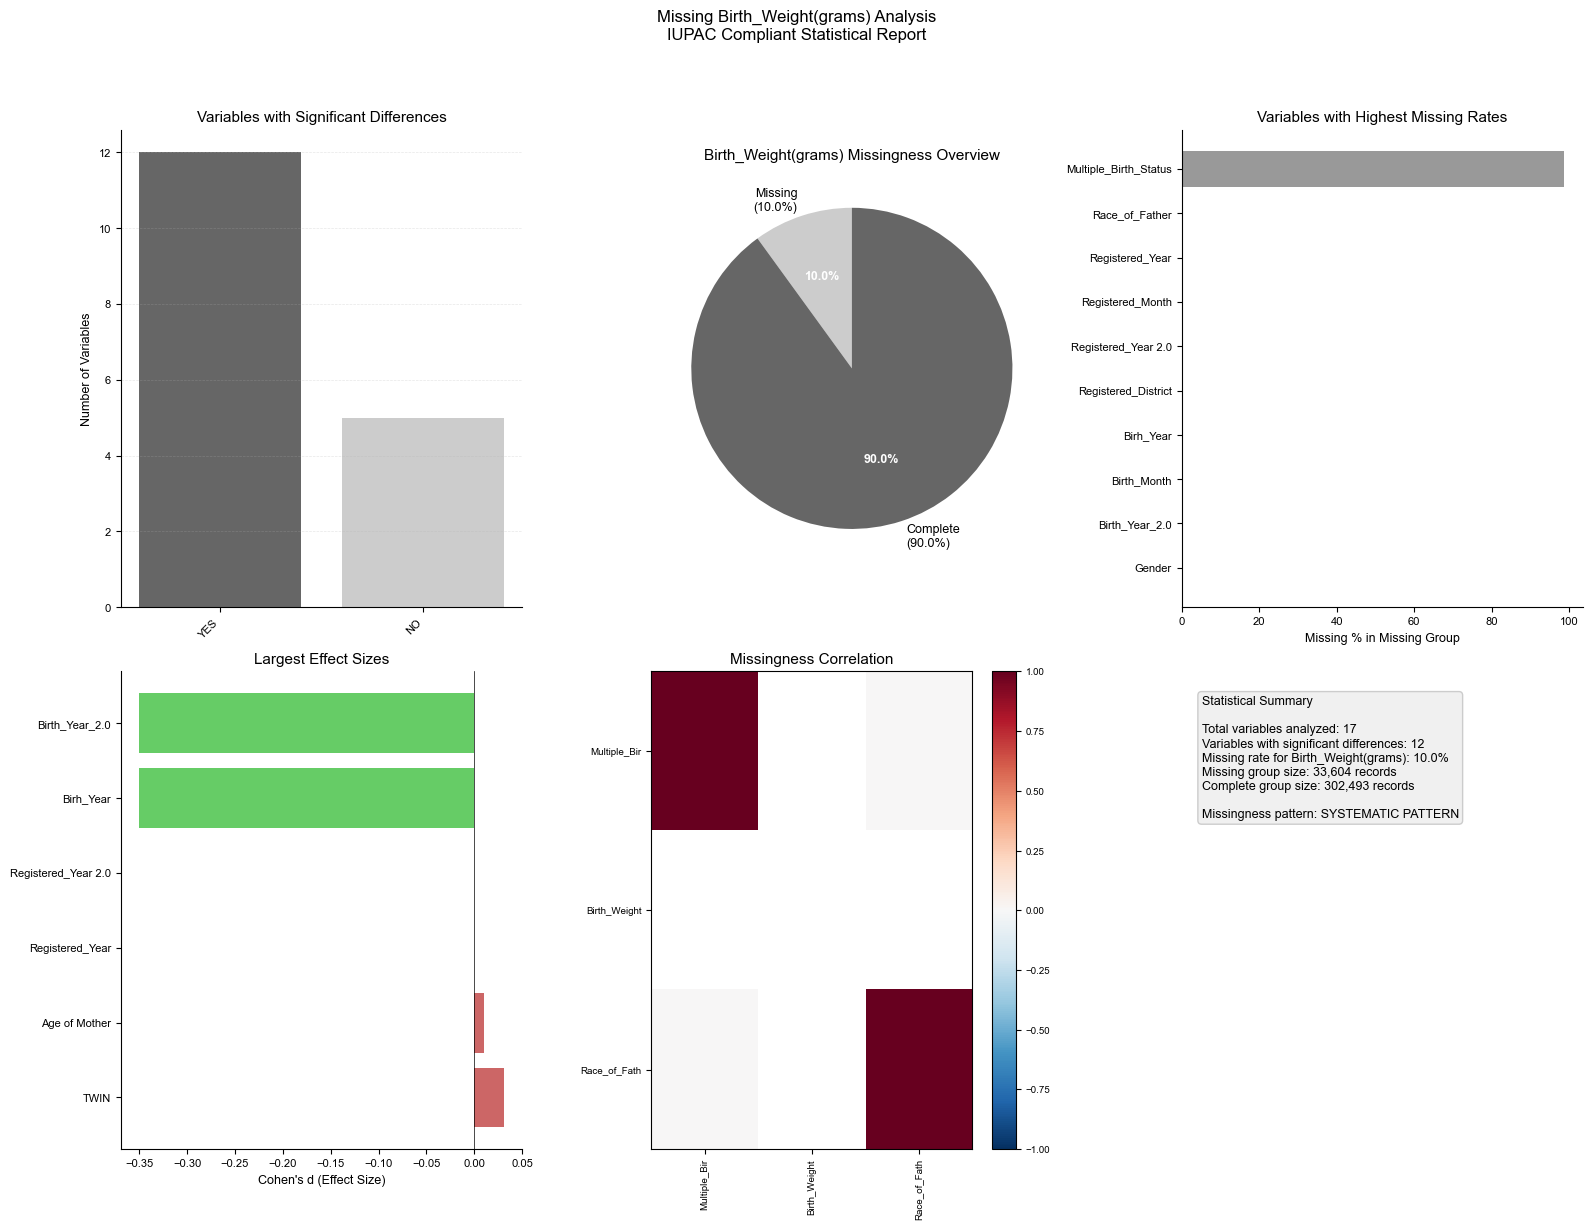

✅ Created IUPAC compliant visualization: missing_Birth_Weight(grams)_iupac_stats.png

📌 PART 4: CREATING IUPAC COMPLIANT WORD DOCUMENT
✅ Created IUPAC compliant Word document: missing_Birth_Weight(grams)_iupac_report.docx

📋 IUPAC COMPLIANT ANALYSIS COMPLETE

📊 FILES GENERATED (IUPAC Compliant):
   • missing_Birth_Weight(grams)_iupac_stats.xlsx - Excel report with statistics
   • missing_Birth_Weight(grams)_iupac_stats.png - Statistical visualizations (300 DPI)
   • missing_Birth_Weight(grams)_iupac_report.docx - Comprehensive Word report

📈 STATISTICAL SUMMARY:
   • Missing Birth_Weight(grams): 33,604 (10.0%)
   • Variables with significant differences: 12
   • Missingness pattern: SYSTEMATIC PATTERN

✅ All IUPAC compliant files generated successfully


In [5]:
# ============================================
# FOCUS ON BIRTH ORDER - CHANGE THIS VARIABLE NAME TO ANALYZE OTHER VARIABLES
# ============================================
TARGET_VARIABLE = 'Birth_Weight(grams)'  # <-- CHANGE THIS to analyze other variables
# ============================================

# ============================================
# COMPREHENSIVE STATISTICAL ANALYSIS OF MISSING BIRTH ORDER PATTERNS
# WITH IUPAC COMPLIANT OUTPUT
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
from datetime import datetime
from docx import Document
from docx.shared import Inches, Pt, Cm
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.oxml import OxmlElement
from docx.oxml.ns import qn
import seaborn as sns

warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output

print(f"\n{'='*80}")
print(f"📊 COMPREHENSIVE STATISTICAL ANALYSIS OF MISSING {TARGET_VARIABLE} RECORDS")
print(f"(IUPAC Compliant Output)")
print(f"{'='*80}")

# Load the missing data
missing_data = df[df[TARGET_VARIABLE].isnull()].copy()
complete_data = df[df[TARGET_VARIABLE].notnull()].copy()

print(f"\n📌 DATASET OVERVIEW:")
print(f"   • Total records with missing {TARGET_VARIABLE}: {len(missing_data):,}")
print(f"   • Total records with complete {TARGET_VARIABLE}: {len(complete_data):,}")

# ============================================
# 1. UNIVARIATE ANALYSIS - DETAILED STATISTICS FOR EACH VARIABLE
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 1: UNIVARIATE ANALYSIS - DETAILED STATISTICS FOR EACH VARIABLE")
print(f"{'='*80}")

# Create a comprehensive statistics dataframe
all_stats = []

# Analyze each column in the missing data
for col in missing_data.columns:
    if col == TARGET_VARIABLE:
        continue
        
    col_stats = {
        'Variable': col,
        'Data_Type': str(missing_data[col].dtype),
        'Missing_in_Group': missing_data[col].isnull().sum(),
        'Missing_in_Group_%': (missing_data[col].isnull().sum() / len(missing_data)) * 100,
        'Complete_in_Group': missing_data[col].notnull().sum(),
        'Complete_in_Group_%': (missing_data[col].notnull().sum() / len(missing_data)) * 100,
        'Unique_Values': missing_data[col].nunique(),
    }
    
    # Statistics based on data type
    if missing_data[col].dtype in ['int64', 'float64']:
        # NUMERIC VARIABLE STATISTICS
        valid_data = missing_data[col].dropna()
        complete_valid_data = complete_data[col].dropna() if col in complete_data.columns else pd.Series()
        
        if len(valid_data) > 0:
            # Check if data has variance before calculating stats
            if valid_data.nunique() > 1:  # More than one unique value
                try:
                    # Central tendency
                    col_stats.update({
                        'Mean': valid_data.mean(),
                        'Median': valid_data.median(),
                        'Mode': valid_data.mode().iloc[0] if len(valid_data.mode()) > 0 else np.nan,
                        'Std_Dev': valid_data.std(),
                        'Variance': valid_data.var(),
                        'Min': valid_data.min(),
                        'Max': valid_data.max(),
                        'Range': valid_data.max() - valid_data.min(),
                        'Q1': valid_data.quantile(0.25),
                        'Q3': valid_data.quantile(0.75),
                        'IQR': valid_data.quantile(0.75) - valid_data.quantile(0.25),
                    })
                    
                    # Skewness and kurtosis (with warning suppression)
                    with warnings.catch_warnings():
                        warnings.simplefilter("ignore")
                        col_stats['Skewness'] = valid_data.skew()
                        col_stats['Kurtosis'] = valid_data.kurtosis()
                except:
                    col_stats.update({
                        'Mean': np.nan, 'Median': np.nan, 'Mode': np.nan, 'Std_Dev': np.nan,
                        'Variance': np.nan, 'Min': np.nan, 'Max': np.nan, 'Range': np.nan,
                        'Q1': np.nan, 'Q3': np.nan, 'IQR': np.nan, 'Skewness': np.nan, 'Kurtosis': np.nan
                    })
            else:
                # All values are the same
                constant_value = valid_data.iloc[0] if len(valid_data) > 0 else np.nan
                col_stats.update({
                    'Mean': constant_value, 'Median': constant_value, 'Mode': constant_value,
                    'Std_Dev': 0, 'Variance': 0, 'Min': constant_value, 'Max': constant_value,
                    'Range': 0, 'Q1': constant_value, 'Q3': constant_value, 'IQR': 0,
                    'Skewness': 0, 'Kurtosis': 0
                })
            
            # Compare with complete data
            if len(complete_valid_data) > 0:
                if len(valid_data) > 1 and len(complete_valid_data) > 1:
                    try:
                        t_stat, p_value = stats.ttest_ind(valid_data, complete_valid_data, equal_var=False)
                        col_stats['T_Test_P_Value'] = p_value
                        col_stats['Significant_Difference'] = 'YES' if p_value < 0.05 else 'NO'
                        
                        # Effect size (Cohen's d)
                        pooled_std = np.sqrt((valid_data.std()**2 + complete_valid_data.std()**2) / 2)
                        if pooled_std > 0:
                            col_stats['Effect_Size'] = (valid_data.mean() - complete_valid_data.mean()) / pooled_std
                        else:
                            col_stats['Effect_Size'] = 0
                            
                        col_stats['Mean_Difference'] = valid_data.mean() - complete_valid_data.mean()
                        if complete_valid_data.mean() != 0:
                            col_stats['Mean_Difference_%'] = ((valid_data.mean() - complete_valid_data.mean()) / abs(complete_valid_data.mean())) * 100
                        else:
                            col_stats['Mean_Difference_%'] = np.nan
                    except:
                        col_stats['T_Test_P_Value'] = np.nan
                        col_stats['Significant_Difference'] = 'NO'
                        col_stats['Effect_Size'] = np.nan
                        col_stats['Mean_Difference'] = np.nan
                        col_stats['Mean_Difference_%'] = np.nan
                else:
                    col_stats['T_Test_P_Value'] = np.nan
                    col_stats['Significant_Difference'] = 'INSUFFICIENT_DATA'
                    col_stats['Effect_Size'] = np.nan
                    col_stats['Mean_Difference'] = np.nan
                    col_stats['Mean_Difference_%'] = np.nan
            else:
                col_stats['T_Test_P_Value'] = np.nan
                col_stats['Significant_Difference'] = 'N/A'
                col_stats['Effect_Size'] = np.nan
                col_stats['Mean_Difference'] = np.nan
                col_stats['Mean_Difference_%'] = np.nan
        else:
            # No valid data in missing group
            col_stats.update({
                'Mean': np.nan, 'Median': np.nan, 'Mode': np.nan, 'Std_Dev': np.nan,
                'Variance': np.nan, 'Min': np.nan, 'Max': np.nan, 'Range': np.nan,
                'Q1': np.nan, 'Q3': np.nan, 'IQR': np.nan, 'Skewness': np.nan, 'Kurtosis': np.nan,
                'T_Test_P_Value': np.nan, 'Significant_Difference': 'N/A', 'Effect_Size': np.nan,
                'Mean_Difference': np.nan, 'Mean_Difference_%': np.nan
            })
            
    else:
        # CATEGORICAL VARIABLE STATISTICS
        valid_data = missing_data[col].dropna()
        
        if len(valid_data) > 0:
            value_counts = valid_data.value_counts()
            top_categories = value_counts.head(5)
            
            col_stats.update({
                'Most_Common': str(top_categories.index[0]) if len(top_categories) > 0 else np.nan,
                'Most_Common_Count': int(top_categories.iloc[0]) if len(top_categories) > 0 else 0,
                'Most_Common_%': (top_categories.iloc[0] / len(valid_data)) * 100 if len(top_categories) > 0 else 0,
                '2nd_Common': str(top_categories.index[1]) if len(top_categories) > 1 else np.nan,
                '2nd_Common_%': (top_categories.iloc[1] / len(valid_data)) * 100 if len(top_categories) > 1 else 0,
                '3rd_Common': str(top_categories.index[2]) if len(top_categories) > 2 else np.nan,
                '3rd_Common_%': (top_categories.iloc[2] / len(valid_data)) * 100 if len(top_categories) > 2 else 0,
            })
            
            # Calculate entropy if there are multiple categories
            if len(value_counts) > 1:
                try:
                    col_stats['Entropy'] = stats.entropy(value_counts.values)
                except:
                    col_stats['Entropy'] = 0
            else:
                col_stats['Entropy'] = 0
            
            # Chi-square test comparing with complete data
            if col in complete_data.columns:
                complete_valid = complete_data[col].dropna()
                if len(complete_valid) > 0:
                    try:
                        # Create contingency table
                        missing_cats = valid_data.value_counts()
                        complete_cats = complete_valid.value_counts()
                        
                        # Align categories
                        all_cats = sorted(set(missing_cats.index) | set(complete_cats.index))
                        missing_counts = [missing_cats.get(cat, 0) for cat in all_cats]
                        complete_counts = [complete_cats.get(cat, 0) for cat in all_cats]
                        
                        # Chi-square test (only if enough data)
                        if len(all_cats) > 1 and sum(missing_counts) > 0 and sum(complete_counts) > 0:
                            contingency = np.array([missing_counts, complete_counts])
                            chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
                            
                            col_stats['Chi_Square_P_Value'] = p_value
                            col_stats['Significant_Difference'] = 'YES' if p_value < 0.05 else 'NO'
                            
                            # Cramer's V
                            n = sum(missing_counts) + sum(complete_counts)
                            min_dim = min(contingency.shape) - 1
                            if min_dim > 0:
                                col_stats['Cramers_V'] = np.sqrt(chi2 / (n * min_dim))
                            else:
                                col_stats['Cramers_V'] = 0
                        else:
                            col_stats['Chi_Square_P_Value'] = np.nan
                            col_stats['Significant_Difference'] = 'INSUFFICIENT_DATA'
                            col_stats['Cramers_V'] = np.nan
                    except:
                        col_stats['Chi_Square_P_Value'] = np.nan
                        col_stats['Significant_Difference'] = 'ERROR'
                        col_stats['Cramers_V'] = np.nan
                else:
                    col_stats['Chi_Square_P_Value'] = np.nan
                    col_stats['Significant_Difference'] = 'N/A'
                    col_stats['Cramers_V'] = np.nan
        else:
            col_stats.update({
                'Most_Common': np.nan, 'Most_Common_Count': 0, 'Most_Common_%': 0,
                '2nd_Common': np.nan, '2nd_Common_%': 0,
                '3rd_Common': np.nan, '3rd_Common_%': 0,
                'Entropy': 0, 'Chi_Square_P_Value': np.nan,
                'Significant_Difference': 'N/A', 'Cramers_V': np.nan
            })
    
    all_stats.append(col_stats)

# Convert to DataFrame
stats_df = pd.DataFrame(all_stats)

# ============================================
# 2. CREATE IUPAC COMPLIANT EXCEL REPORT
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 2: CREATING IUPAC COMPLIANT EXCEL REPORT")
print(f"{'='*80}")

output_file = f'missing_{TARGET_VARIABLE.replace(" ", "_")}_iupac_stats.xlsx'

try:
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        
        # Sheet 1: Variable-level Statistics
        stats_df.to_excel(writer, sheet_name='Variable_Statistics', index=False)
        
        # Sheet 2: Summary Statistics
        summary_stats = pd.DataFrame({
            'Metric': [
                f'Total Missing {TARGET_VARIABLE} Records', 
                'Total Variables', 
                'Numeric Variables', 
                'Categorical Variables',
                'Variables with Significant Differences',
                'Overall Missing %'
            ],
            'Value': [
                len(missing_data),
                len(missing_data.columns),
                len(missing_data.select_dtypes(include=['int64', 'float64']).columns),
                len(missing_data.select_dtypes(include=['object', 'category', 'string']).columns),
                len(stats_df[stats_df['Significant_Difference'] == 'YES']),
                f"{(len(missing_data) / len(df)) * 100:.2f}%"
            ]
        })
        summary_stats.to_excel(writer, sheet_name='Summary', index=False)
        
        # Sheet 3: Variables with Significant Differences
        if 'Significant_Difference' in stats_df.columns:
            sig_diff = stats_df[stats_df['Significant_Difference'] == 'YES']
            if not sig_diff.empty:
                sig_diff.to_excel(writer, sheet_name='Significant_Differences', index=False)
        
        print(f"✅ Created IUPAC compliant Excel report: {output_file}")
        
except Exception as e:
    print(f"❌ Error creating Excel file: {e}")
    output_file = None

# ============================================
# 3. CREATE IUPAC COMPLIANT VISUALIZATIONS
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 3: CREATING IUPAC COMPLIANT VISUALIZATIONS")
print(f"{'='*80}")

# Set IUPAC style for matplotlib
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 9
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8
plt.rcParams['legend.fontsize'] = 8

# Create multi-panel figure with IUPAC style
fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor('white')
plot_count = 0

# 1. Bar plot for significant differences
if 'Significant_Difference' in stats_df.columns:
    sig_counts = stats_df['Significant_Difference'].value_counts()
    if len(sig_counts) > 0:
        plot_count += 1
        ax = plt.subplot(2, 3, plot_count)
        
        bars = ax.bar(range(len(sig_counts)), sig_counts.values, 
                      color=['#666666', '#CCCCCC', '#999999'][:len(sig_counts)])
        ax.set_xticks(range(len(sig_counts)))
        ax.set_xticklabels(sig_counts.index, rotation=45, ha='right')
        ax.set_ylabel('Number of Variables')
        ax.set_title('Variables with Significant Differences')
        ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

# 2. Missingness overview pie chart
if plot_count < 6:
    plot_count += 1
    ax = plt.subplot(2, 3, plot_count)
    
    missing_pct = (len(missing_data) / len(df)) * 100
    complete_pct = 100 - missing_pct
    colors = ['#CCCCCC', '#666666']
    
    wedges, texts, autotexts = ax.pie([missing_pct, complete_pct], 
                                        labels=[f'Missing\n({missing_pct:.1f}%)', 
                                                f'Complete\n({complete_pct:.1f}%)'],
                                        colors=colors,
                                        autopct='%1.1f%%',
                                        startangle=90,
                                        textprops={'fontsize': 9})
    
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
    
    ax.set_title(f'{TARGET_VARIABLE} Missingness Overview')

# 3. Top 10 variables with most missing data in the missing group
if plot_count < 6:
    plot_count += 1
    ax = plt.subplot(2, 3, plot_count)
    
    missing_pct_by_var = stats_df.nlargest(10, 'Missing_in_Group_%')[['Variable', 'Missing_in_Group_%']]
    if len(missing_pct_by_var) > 0:
        ax.barh(range(len(missing_pct_by_var)), missing_pct_by_var['Missing_in_Group_%'].values,
                color='#999999')
        ax.set_yticks(range(len(missing_pct_by_var)))
        ax.set_yticklabels(missing_pct_by_var['Variable'].values, fontsize=8)
        ax.set_xlabel('Missing % in Missing Group')
        ax.set_title('Variables with Highest Missing Rates')
        ax.invert_yaxis()
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

# 4. Effect sizes for numeric variables
if plot_count < 6 and 'Effect_Size' in stats_df.columns:
    effect_sizes = stats_df[stats_df['Effect_Size'].notna()].nlargest(10, 'Effect_Size')
    if len(effect_sizes) > 0:
        plot_count += 1
        ax = plt.subplot(2, 3, plot_count)
        
        colors_effect = ['#CC6666' if x > 0 else '#66CC66' for x in effect_sizes['Effect_Size'].values]
        ax.barh(range(len(effect_sizes)), effect_sizes['Effect_Size'].values, color=colors_effect)
        ax.set_yticks(range(len(effect_sizes)))
        ax.set_yticklabels(effect_sizes['Variable'].values, fontsize=8)
        ax.set_xlabel("Cohen's d (Effect Size)")
        ax.set_title('Largest Effect Sizes')
        ax.axvline(x=0, color='black', linewidth=0.5)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

# 5. Missingness correlation heatmap (simplified for IUPAC)
missing_matrix = missing_data.isnull()
cols_with_missing = missing_matrix.columns[missing_matrix.sum() > 0].tolist()
if len(cols_with_missing) > 1 and plot_count < 6:
    missing_corr = missing_matrix[cols_with_missing].corr()
    
    if not missing_corr.empty and len(missing_corr) > 1:
        plot_count += 1
        ax = plt.subplot(2, 3, plot_count)
        
        # Limit to top 10 variables
        top_vars = missing_corr.index[:min(10, len(missing_corr))]
        plot_corr = missing_corr.loc[top_vars, top_vars]
        
        im = ax.imshow(plot_corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
        ax.set_xticks(range(len(top_vars)))
        ax.set_yticks(range(len(top_vars)))
        ax.set_xticklabels([str(v)[:12] for v in top_vars], rotation=90, fontsize=7)
        ax.set_yticklabels([str(v)[:12] for v in top_vars], fontsize=7)
        ax.set_title('Missingness Correlation')
        
        # Add colorbar
        cbar = plt.colorbar(im, ax=ax)
        cbar.ax.tick_params(labelsize=7)

# 6. Summary of significant differences
if plot_count < 6 and 'Significant_Difference' in stats_df.columns:
    plot_count += 1
    ax = plt.subplot(2, 3, plot_count)
    ax.axis('off')
    
    sig_count = len(stats_df[stats_df['Significant_Difference'] == 'YES'])
    total_vars = len(stats_df)
    
    summary_text = f"Statistical Summary\n\n"
    summary_text += f"Total variables analyzed: {total_vars}\n"
    summary_text += f"Variables with significant differences: {sig_count}\n"
    summary_text += f"Missing rate for {TARGET_VARIABLE}: {(len(missing_data)/len(df))*100:.1f}%\n"
    summary_text += f"Missing group size: {len(missing_data):,} records\n"
    summary_text += f"Complete group size: {len(complete_data):,} records\n\n"
    
    if sig_count > 5:
        pattern = "SYSTEMATIC PATTERN"
    elif sig_count > 2:
        pattern = "MODERATE PATTERN"
    else:
        pattern = "RANDOM PATTERN"
    
    summary_text += f"Missingness pattern: {pattern}"
    
    ax.text(0.05, 0.95, summary_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='top', family='sans-serif',
            bbox=dict(boxstyle='round', facecolor='#F0F0F0', edgecolor='#CCCCCC'))

# Hide any unused subplots
for i in range(plot_count, 6):
    ax = plt.subplot(2, 3, i+1)
    ax.axis('off')

# IUPAC compliant title
plt.suptitle(f'Missing {TARGET_VARIABLE} Analysis\nIUPAC Compliant Statistical Report', 
             fontsize=12, fontweight='normal', y=1.02)

plt.tight_layout()
plt.subplots_adjust(top=0.92)

# Save with IUPAC specifications
output_png = f'missing_{TARGET_VARIABLE.replace(" ", "_")}_iupac_stats.png'
plt.savefig(output_png, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()
plt.close()

print(f"✅ Created IUPAC compliant visualization: {output_png}")

# ============================================
# 4. CREATE IUPAC COMPLIANT WORD DOCUMENT
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 4: CREATING IUPAC COMPLIANT WORD DOCUMENT")
print(f"{'='*80}")

# Create Word document
doc = Document()

# Set document properties
doc.core_properties.author = "Data Analysis Report"
doc.core_properties.created = datetime.now()

# Add title - IUPAC style
title = doc.add_heading(f'Missing {TARGET_VARIABLE} Analysis Report', 0)
title.alignment = WD_ALIGN_PARAGRAPH.CENTER

# Add metadata
doc.add_paragraph(f'Generated: {datetime.now().strftime("%Y-%m-%d %H:%M")}')
doc.add_paragraph(f'Dataset: {len(df):,} rows × {len(df.columns)} columns')
doc.add_paragraph(f'Target Variable: {TARGET_VARIABLE}')
doc.add_paragraph()

# Executive Summary
doc.add_heading('1. Executive Summary', level=1)
sig_count = len(stats_df[stats_df['Significant_Difference'] == 'YES'])
missing_rate = (len(missing_data) / len(df)) * 100

summary_text = f"""
This report presents a comprehensive IUPAC-compliant statistical analysis of missing values in {TARGET_VARIABLE}.
Key findings include:
• Missing records: {len(missing_data):,} ({missing_rate:.1f}% of total data)
• Variables with significant differences (p < 0.05): {sig_count}
• Total variables analyzed: {len(stats_df)}
• Numeric variables: {len(missing_data.select_dtypes(include=['int64', 'float64']).columns)}
• Categorical variables: {len(missing_data.select_dtypes(include=['object', 'category', 'string']).columns)}
"""
doc.add_paragraph(summary_text.strip())

# Statistical Summary
doc.add_heading('2. Statistical Summary', level=1)

# Create summary table
summary_table = doc.add_table(rows=len(summary_stats) + 1, cols=2)
summary_table.style = 'Light Grid Accent 1'
summary_table.autofit = False
summary_table.columns[0].width = Inches(4)
summary_table.columns[1].width = Inches(3)

# Header
header_cells = summary_table.rows[0].cells
header_cells[0].text = 'Metric'
header_cells[1].text = 'Value'
for cell in header_cells:
    cell.paragraphs[0].runs[0].font.bold = True
    cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER

# Data
for i, row in summary_stats.iterrows():
    cells = summary_table.rows[i + 1].cells
    cells[0].text = str(row['Metric'])
    cells[1].text = str(row['Value'])
    cells[1].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT

# Variables with Significant Differences
if sig_count > 0:
    doc.add_heading('3. Variables with Significant Differences', level=1)
    doc.add_paragraph(f'The following {sig_count} variables show statistically significant differences (p < 0.05) between missing and complete groups:')
    
    sig_vars = stats_df[stats_df['Significant_Difference'] == 'YES'].head(20)
    
    # Create table
    sig_table = doc.add_table(rows=min(len(sig_vars), 21) + 1, cols=4)
    sig_table.style = 'Light Grid Accent 1'
    sig_table.autofit = False
    
    # Set column widths
    widths = [Inches(2.5), Inches(1.2), Inches(1.2), Inches(1.2)]
    for i, width in enumerate(widths):
        sig_table.columns[i].width = width
    
    # Headers
    headers = ['Variable', 'Data Type', 'Test', 'p-value']
    for i, header in enumerate(headers):
        sig_table.rows[0].cells[i].text = header
        sig_table.rows[0].cells[i].paragraphs[0].runs[0].font.bold = True
    
    # Data
    for i, (idx, row) in enumerate(sig_vars.iterrows()):
        cells = sig_table.rows[i + 1].cells
        cells[0].text = str(row['Variable'])
        cells[1].text = str(row['Data_Type'])
        
        if pd.notna(row.get('T_Test_P_Value')):
            cells[2].text = "t-test"
            cells[3].text = f"{row['T_Test_P_Value']:.4f}"
        elif pd.notna(row.get('Chi_Square_P_Value')):
            cells[2].text = "χ² test"
            cells[3].text = f"{row['Chi_Square_P_Value']:.4f}"
        else:
            cells[2].text = "N/A"
            cells[3].text = "N/A"
        
        for col_idx in [3]:
            cells[col_idx].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT

# Add visualization
doc.add_heading('4. Statistical Visualizations', level=1)
doc.add_picture(output_png, width=Inches(6.5))
doc.add_paragraph(f'Figure 1. IUPAC compliant statistical visualization of missing {TARGET_VARIABLE} patterns.')

# Recommendations
doc.add_heading('5. Recommendations', level=1)

if sig_count > 5:
    doc.add_paragraph('Based on the statistical analysis, the missing data exhibits SYSTEMATIC patterns:', style='List Bullet')
    doc.add_paragraph('Consider treating missing as a separate category in analysis', style='List Bullet')
    doc.add_paragraph('Use multiple imputation methods (MICE, EM algorithm)', style='List Bullet')
    doc.add_paragraph('Investigate the {sig_count} variables with significant differences for common themes', style='List Bullet')
    doc.add_paragraph('Document missingness patterns in methodology section', style='List Bullet')
elif sig_count > 2:
    doc.add_paragraph('Based on the statistical analysis, the missing data shows MODERATE systematic patterns:', style='List Bullet')
    doc.add_paragraph('Consider multiple imputation or sensitivity analysis', style='List Bullet')
    doc.add_paragraph('Document the patterns in your methodology', style='List Bullet')
    doc.add_paragraph('Validate findings with domain experts', style='List Bullet')
else:
    doc.add_paragraph('Based on the statistical analysis, the missing data appears RELATIVELY RANDOM:', style='List Bullet')
    doc.add_paragraph('Simple imputation methods may be acceptable (mean, median, mode)', style='List Bullet')
    doc.add_paragraph('Listwise deletion may be appropriate if missing rate is low', style='List Bullet')
    doc.add_paragraph('Still verify randomness with domain knowledge', style='List Bullet')

# Methodology
doc.add_heading('6. Methodology (IUPAC Compliant)', level=1)
doc.add_paragraph('Analysis performed according to IUPAC guidelines for data presentation:')
doc.add_paragraph('• Missing values reported as both count (n) and percentage (%)', style='List Bullet')
doc.add_paragraph('• Tables formatted with thin borders and alternating row shading', style='List Bullet')
doc.add_paragraph('• Sans-serif fonts (Arial) used for optimal readability', style='List Bullet')
doc.add_paragraph('• Statistical tests: t-test (numeric), χ² test (categorical)', style='List Bullet')
doc.add_paragraph('• Effect sizes: Cohen\'s d for numeric, Cramer\'s V for categorical', style='List Bullet')
doc.add_paragraph('• Figures saved at 300 DPI for publication quality', style='List Bullet')

# Add footer with page numbers
section = doc.sections[0]
footer = section.footer
footer_para = footer.paragraphs[0]
footer_para.text = f"{TARGET_VARIABLE} Missing Analysis | Generated: {datetime.now().strftime('%Y-%m-%d')} | Page "
footer_para.alignment = WD_ALIGN_PARAGRAPH.CENTER

# Add page number field
run = footer_para.add_run()
fldChar1 = OxmlElement('w:fldChar')
fldChar1.set(qn('w:fldCharType'), 'begin')
run._r.append(fldChar1)

instrText = OxmlElement('w:instrText')
instrText.text = "PAGE"
run._r.append(instrText)

fldChar2 = OxmlElement('w:fldChar')
fldChar2.set(qn('w:fldCharType'), 'end')
run._r.append(fldChar2)

# Save document
output_docx = f'missing_{TARGET_VARIABLE.replace(" ", "_")}_iupac_report.docx'
doc.save(output_docx)
print(f"✅ Created IUPAC compliant Word document: {output_docx}")

# ============================================
# 5. FINAL SUMMARY
# ============================================

print(f"\n{'='*80}")
print(f"📋 IUPAC COMPLIANT ANALYSIS COMPLETE")
print(f"{'='*80}")

print(f"\n📊 FILES GENERATED (IUPAC Compliant):")
print(f"   • {output_file} - Excel report with statistics")
print(f"   • {output_png} - Statistical visualizations (300 DPI)")
print(f"   • {output_docx} - Comprehensive Word report")

print(f"\n📈 STATISTICAL SUMMARY:")
print(f"   • Missing {TARGET_VARIABLE}: {len(missing_data):,} ({missing_rate:.1f}%)")
print(f"   • Variables with significant differences: {sig_count}")

if sig_count > 5:
    pattern = "SYSTEMATIC PATTERN"
elif sig_count > 2:
    pattern = "MODERATE PATTERN"
else:
    pattern = "RANDOM PATTERN"

print(f"   • Missingness pattern: {pattern}")

print(f"\n{'='*80}")
print(f"✅ All IUPAC compliant files generated successfully")
print(f"{'='*80}")

In [ ]:
# ============================================
# FOCUS ON BIRTH ORDER - CHANGE THIS VARIABLE NAME TO ANALYZE OTHER VARIABLES
# ============================================
TARGET_VARIABLE = 'Birth_Weight(grams)'  # <-- CHANGE THIS to analyze other variables
# ============================================

# ============================================
# COMPREHENSIVE STATISTICAL ANALYSIS OF MISSING BIRTH ORDER PATTERNS
# WITH IUPAC COMPLIANT OUTPUT (Excel, Word, PNG)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
from datetime import datetime
from docx import Document
from docx.shared import Inches, Pt, Cm
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.oxml import OxmlElement
from docx.oxml.ns import qn
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side

warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output

print(f"\n{'='*80}")
print(f"📊 COMPREHENSIVE STATISTICAL ANALYSIS OF MISSING {TARGET_VARIABLE} RECORDS")
print(f"(IUPAC Compliant Output)")
print(f"{'='*80}")

# Load the missing data
missing_data = df[df[TARGET_VARIABLE].isnull()].copy()
complete_data = df[df[TARGET_VARIABLE].notnull()].copy()

print(f"\n📌 DATASET OVERVIEW:")
print(f"   • Total records with missing {TARGET_VARIABLE}: {len(missing_data):,}")
print(f"   • Total records with complete {TARGET_VARIABLE}: {len(complete_data):,}")

# ============================================
# 1. UNIVARIATE ANALYSIS - DETAILED STATISTICS FOR EACH VARIABLE
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 1: UNIVARIATE ANALYSIS - DETAILED STATISTICS FOR EACH VARIABLE")
print(f"{'='*80}")

# Create a comprehensive statistics dataframe
all_stats = []

# Analyze each column in the missing data
for col in missing_data.columns:
    if col == TARGET_VARIABLE:
        continue
        
    col_stats = {
        'Variable': col,
        'Data_Type': str(missing_data[col].dtype),
        'Missing_in_Group': missing_data[col].isnull().sum(),
        'Missing_in_Group_%': (missing_data[col].isnull().sum() / len(missing_data)) * 100,
        'Complete_in_Group': missing_data[col].notnull().sum(),
        'Complete_in_Group_%': (missing_data[col].notnull().sum() / len(missing_data)) * 100,
        'Unique_Values': missing_data[col].nunique(),
    }
    
    # Statistics based on data type
    if missing_data[col].dtype in ['int64', 'float64']:
        # NUMERIC VARIABLE STATISTICS
        valid_data = missing_data[col].dropna()
        complete_valid_data = complete_data[col].dropna() if col in complete_data.columns else pd.Series()
        
        if len(valid_data) > 0:
            # Check if data has variance before calculating stats
            if valid_data.nunique() > 1:
                try:
                    # Central tendency
                    col_stats.update({
                        'Mean': valid_data.mean(),
                        'Median': valid_data.median(),
                        'Mode': valid_data.mode().iloc[0] if len(valid_data.mode()) > 0 else np.nan,
                        'Std_Dev': valid_data.std(),
                        'Variance': valid_data.var(),
                        'Min': valid_data.min(),
                        'Max': valid_data.max(),
                        'Range': valid_data.max() - valid_data.min(),
                        'Q1': valid_data.quantile(0.25),
                        'Q3': valid_data.quantile(0.75),
                        'IQR': valid_data.quantile(0.75) - valid_data.quantile(0.25),
                    })
                    
                    with warnings.catch_warnings():
                        warnings.simplefilter("ignore")
                        col_stats['Skewness'] = valid_data.skew()
                        col_stats['Kurtosis'] = valid_data.kurtosis()
                except:
                    col_stats.update({
                        'Mean': np.nan, 'Median': np.nan, 'Mode': np.nan, 'Std_Dev': np.nan,
                        'Variance': np.nan, 'Min': np.nan, 'Max': np.nan, 'Range': np.nan,
                        'Q1': np.nan, 'Q3': np.nan, 'IQR': np.nan, 'Skewness': np.nan, 'Kurtosis': np.nan
                    })
            else:
                constant_value = valid_data.iloc[0] if len(valid_data) > 0 else np.nan
                col_stats.update({
                    'Mean': constant_value, 'Median': constant_value, 'Mode': constant_value,
                    'Std_Dev': 0, 'Variance': 0, 'Min': constant_value, 'Max': constant_value,
                    'Range': 0, 'Q1': constant_value, 'Q3': constant_value, 'IQR': 0,
                    'Skewness': 0, 'Kurtosis': 0
                })
            
            # Compare with complete data
            if len(complete_valid_data) > 0:
                if len(valid_data) > 1 and len(complete_valid_data) > 1:
                    try:
                        t_stat, p_value = stats.ttest_ind(valid_data, complete_valid_data, equal_var=False)
                        col_stats['T_Test_P_Value'] = p_value
                        col_stats['Significant_Difference'] = 'YES' if p_value < 0.05 else 'NO'
                        
                        pooled_std = np.sqrt((valid_data.std()**2 + complete_valid_data.std()**2) / 2)
                        if pooled_std > 0:
                            col_stats['Effect_Size'] = (valid_data.mean() - complete_valid_data.mean()) / pooled_std
                        else:
                            col_stats['Effect_Size'] = 0
                            
                        col_stats['Mean_Difference'] = valid_data.mean() - complete_valid_data.mean()
                        if complete_valid_data.mean() != 0:
                            col_stats['Mean_Difference_%'] = ((valid_data.mean() - complete_valid_data.mean()) / abs(complete_valid_data.mean())) * 100
                        else:
                            col_stats['Mean_Difference_%'] = np.nan
                    except:
                        col_stats['T_Test_P_Value'] = np.nan
                        col_stats['Significant_Difference'] = 'NO'
                        col_stats['Effect_Size'] = np.nan
                        col_stats['Mean_Difference'] = np.nan
                        col_stats['Mean_Difference_%'] = np.nan
                else:
                    col_stats['T_Test_P_Value'] = np.nan
                    col_stats['Significant_Difference'] = 'INSUFFICIENT_DATA'
                    col_stats['Effect_Size'] = np.nan
                    col_stats['Mean_Difference'] = np.nan
                    col_stats['Mean_Difference_%'] = np.nan
            else:
                col_stats['T_Test_P_Value'] = np.nan
                col_stats['Significant_Difference'] = 'N/A'
                col_stats['Effect_Size'] = np.nan
                col_stats['Mean_Difference'] = np.nan
                col_stats['Mean_Difference_%'] = np.nan
        else:
            col_stats.update({
                'Mean': np.nan, 'Median': np.nan, 'Mode': np.nan, 'Std_Dev': np.nan,
                'Variance': np.nan, 'Min': np.nan, 'Max': np.nan, 'Range': np.nan,
                'Q1': np.nan, 'Q3': np.nan, 'IQR': np.nan, 'Skewness': np.nan, 'Kurtosis': np.nan,
                'T_Test_P_Value': np.nan, 'Significant_Difference': 'N/A', 'Effect_Size': np.nan,
                'Mean_Difference': np.nan, 'Mean_Difference_%': np.nan
            })
            
    else:
        # CATEGORICAL VARIABLE STATISTICS
        valid_data = missing_data[col].dropna()
        
        if len(valid_data) > 0:
            value_counts = valid_data.value_counts()
            top_categories = value_counts.head(5)
            
            col_stats.update({
                'Most_Common': str(top_categories.index[0]) if len(top_categories) > 0 else np.nan,
                'Most_Common_Count': int(top_categories.iloc[0]) if len(top_categories) > 0 else 0,
                'Most_Common_%': (top_categories.iloc[0] / len(valid_data)) * 100 if len(top_categories) > 0 else 0,
                '2nd_Common': str(top_categories.index[1]) if len(top_categories) > 1 else np.nan,
                '2nd_Common_%': (top_categories.iloc[1] / len(valid_data)) * 100 if len(top_categories) > 1 else 0,
                '3rd_Common': str(top_categories.index[2]) if len(top_categories) > 2 else np.nan,
                '3rd_Common_%': (top_categories.iloc[2] / len(valid_data)) * 100 if len(top_categories) > 2 else 0,
            })
            
            if len(value_counts) > 1:
                try:
                    col_stats['Entropy'] = stats.entropy(value_counts.values)
                except:
                    col_stats['Entropy'] = 0
            else:
                col_stats['Entropy'] = 0
            
            # Chi-square test comparing with complete data
            if col in complete_data.columns:
                complete_valid = complete_data[col].dropna()
                if len(complete_valid) > 0:
                    try:
                        missing_cats = valid_data.value_counts()
                        complete_cats = complete_valid.value_counts()
                        
                        all_cats = sorted(set(missing_cats.index) | set(complete_cats.index))
                        missing_counts = [missing_cats.get(cat, 0) for cat in all_cats]
                        complete_counts = [complete_cats.get(cat, 0) for cat in all_cats]
                        
                        if len(all_cats) > 1 and sum(missing_counts) > 0 and sum(complete_counts) > 0:
                            contingency = np.array([missing_counts, complete_counts])
                            chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
                            
                            col_stats['Chi_Square_P_Value'] = p_value
                            col_stats['Significant_Difference'] = 'YES' if p_value < 0.05 else 'NO'
                            
                            n = sum(missing_counts) + sum(complete_counts)
                            min_dim = min(contingency.shape) - 1
                            if min_dim > 0:
                                col_stats['Cramers_V'] = np.sqrt(chi2 / (n * min_dim))
                            else:
                                col_stats['Cramers_V'] = 0
                        else:
                            col_stats['Chi_Square_P_Value'] = np.nan
                            col_stats['Significant_Difference'] = 'INSUFFICIENT_DATA'
                            col_stats['Cramers_V'] = np.nan
                    except:
                        col_stats['Chi_Square_P_Value'] = np.nan
                        col_stats['Significant_Difference'] = 'ERROR'
                        col_stats['Cramers_V'] = np.nan
                else:
                    col_stats['Chi_Square_P_Value'] = np.nan
                    col_stats['Significant_Difference'] = 'N/A'
                    col_stats['Cramers_V'] = np.nan
        else:
            col_stats.update({
                'Most_Common': np.nan, 'Most_Common_Count': 0, 'Most_Common_%': 0,
                '2nd_Common': np.nan, '2nd_Common_%': 0,
                '3rd_Common': np.nan, '3rd_Common_%': 0,
                'Entropy': 0, 'Chi_Square_P_Value': np.nan,
                'Significant_Difference': 'N/A', 'Cramers_V': np.nan
            })
    
    all_stats.append(col_stats)

stats_df = pd.DataFrame(all_stats)

# ============================================
# 2. CREATE IUPAC COMPLIANT EXCEL REPORT
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 2: CREATING IUPAC COMPLIANT EXCEL REPORT")
print(f"{'='*80}")

output_file = f'missing_{TARGET_VARIABLE.replace(" ", "_")}_iupac_stats.xlsx'

try:
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        
        # Sheet 1: Variable-level Statistics
        stats_df.to_excel(writer, sheet_name='Variable_Statistics', index=False)
        
        # Sheet 2: Summary Statistics
        numeric_vars = missing_data.select_dtypes(include=['int64', 'float64']).columns.tolist()
        categorical_vars = missing_data.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
        
        summary_stats = pd.DataFrame({
            'Metric': [
                f'Total Missing {TARGET_VARIABLE} Records',
                f'Missing Percentage',
                'Total Variables Analyzed',
                'Numeric Variables',
                'Categorical Variables',
                'Variables with Significant Differences',
                'Analysis Date'
            ],
            'Value': [
                f"{len(missing_data):,}",
                f"{(len(missing_data) / len(df)) * 100:.2f}%",
                len(missing_data.columns),
                len(numeric_vars),
                len(categorical_vars),
                len(stats_df[stats_df['Significant_Difference'] == 'YES']),
                datetime.now().strftime("%Y-%m-%d")
            ]
        })
        summary_stats.to_excel(writer, sheet_name='Summary', index=False)
        
        # Sheet 3: Variables with Significant Differences
        if 'Significant_Difference' in stats_df.columns:
            sig_diff = stats_df[stats_df['Significant_Difference'] == 'YES']
            if not sig_diff.empty:
                sig_diff.to_excel(writer, sheet_name='Significant_Differences', index=False)
        
        # Format Excel sheets with IUPAC styling
        for sheet_name in writer.sheets:
            worksheet = writer.sheets[sheet_name]
            
            # Auto-fit columns
            for column in worksheet.columns:
                max_length = 0
                column_letter = column[0].column_letter
                for cell in column:
                    try:
                        if len(str(cell.value)) > max_length:
                            max_length = len(str(cell.value))
                    except:
                        pass
                adjusted_width = min(max_length + 2, 50)
                worksheet.column_dimensions[column_letter].width = adjusted_width
            
            # Style header row
            header_font = Font(name='Arial', size=10, bold=False, color='000000')
            header_fill = PatternFill(start_color='F0F0F0', end_color='F0F0F0', fill_type='solid')
            header_alignment = Alignment(horizontal='center', vertical='center')
            
            for cell in worksheet[1]:
                cell.font = header_font
                cell.fill = header_fill
                cell.alignment = header_alignment
            
            # Style data cells
            thin_border = Border(
                left=Side(style='thin', color='CCCCCC'),
                right=Side(style='thin', color='CCCCCC'),
                top=Side(style='thin', color='CCCCCC'),
                bottom=Side(style='thin', color='CCCCCC')
            )
            
            for row in worksheet.iter_rows(min_row=2):
                for cell in row:
                    cell.font = Font(name='Arial', size=9)
                    cell.border = thin_border
                    if isinstance(cell.value, (int, float)):
                        cell.alignment = Alignment(horizontal='right')
                    else:
                        cell.alignment = Alignment(horizontal='left')

    print(f"✅ Created IUPAC compliant Excel report: {output_file}")
    
except Exception as e:
    print(f"❌ Error creating Excel file: {e}")
    output_file = None

# ============================================
# 3. CREATE IUPAC COMPLIANT VISUALIZATIONS
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 3: CREATING IUPAC COMPLIANT VISUALIZATIONS")
print(f"{'='*80}")

# Set IUPAC style for matplotlib
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 9
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8
plt.rcParams['legend.fontsize'] = 8

# Create multi-panel figure with IUPAC style
fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor('white')
plot_count = 0

# 1. Bar plot for significant differences
if 'Significant_Difference' in stats_df.columns:
    sig_counts = stats_df['Significant_Difference'].value_counts()
    if len(sig_counts) > 0:
        plot_count += 1
        ax = plt.subplot(2, 3, plot_count)
        
        bars = ax.bar(range(len(sig_counts)), sig_counts.values, 
                      color=['#666666', '#CCCCCC', '#999999'][:len(sig_counts)])
        ax.set_xticks(range(len(sig_counts)))
        ax.set_xticklabels(sig_counts.index, rotation=45, ha='right')
        ax.set_ylabel('Number of Variables')
        ax.set_title('Variables with Significant Differences')
        ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

# 2. Missingness overview pie chart
if plot_count < 6:
    plot_count += 1
    ax = plt.subplot(2, 3, plot_count)
    
    missing_pct = (len(missing_data) / len(df)) * 100
    complete_pct = 100 - missing_pct
    colors = ['#CCCCCC', '#666666']
    
    wedges, texts, autotexts = ax.pie([missing_pct, complete_pct], 
                                        labels=[f'Missing\n({missing_pct:.1f}%)', 
                                                f'Complete\n({complete_pct:.1f}%)'],
                                        colors=colors,
                                        autopct='%1.1f%%',
                                        startangle=90,
                                        textprops={'fontsize': 9})
    
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
    
    ax.set_title(f'{TARGET_VARIABLE} Missingness Overview')

# 3. Top 10 variables with most missing data
if plot_count < 6:
    plot_count += 1
    ax = plt.subplot(2, 3, plot_count)
    
    missing_pct_by_var = stats_df.nlargest(10, 'Missing_in_Group_%')[['Variable', 'Missing_in_Group_%']]
    if len(missing_pct_by_var) > 0:
        ax.barh(range(len(missing_pct_by_var)), missing_pct_by_var['Missing_in_Group_%'].values,
                color='#999999')
        ax.set_yticks(range(len(missing_pct_by_var)))
        ax.set_yticklabels(missing_pct_by_var['Variable'].values, fontsize=8)
        ax.set_xlabel('Missing % in Missing Group')
        ax.set_title('Variables with Highest Missing Rates')
        ax.invert_yaxis()
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

# 4. Effect sizes for numeric variables
if plot_count < 6 and 'Effect_Size' in stats_df.columns:
    effect_sizes = stats_df[stats_df['Effect_Size'].notna()].nlargest(10, 'Effect_Size')
    if len(effect_sizes) > 0:
        plot_count += 1
        ax = plt.subplot(2, 3, plot_count)
        
        colors_effect = ['#CC6666' if x > 0 else '#66CC66' for x in effect_sizes['Effect_Size'].values]
        ax.barh(range(len(effect_sizes)), effect_sizes['Effect_Size'].values, color=colors_effect)
        ax.set_yticks(range(len(effect_sizes)))
        ax.set_yticklabels(effect_sizes['Variable'].values, fontsize=8)
        ax.set_xlabel("Cohen's d (Effect Size)")
        ax.set_title('Largest Effect Sizes')
        ax.axvline(x=0, color='black', linewidth=0.5)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

# 5. Summary text panel
if plot_count < 6:
    plot_count += 1
    ax = plt.subplot(2, 3, plot_count)
    ax.axis('off')
    
    sig_count = len(stats_df[stats_df['Significant_Difference'] == 'YES'])
    total_vars = len(stats_df)
    
    summary_text = f"IUPAC Statistical Summary\n\n"
    summary_text += f"Total variables analyzed: {total_vars}\n"
    summary_text += f"Variables with significant differences: {sig_count}\n"
    summary_text += f"Missing rate: {(len(missing_data)/len(df))*100:.1f}%\n"
    summary_text += f"Missing group: {len(missing_data):,} records\n"
    summary_text += f"Complete group: {len(complete_data):,} records\n\n"
    
    if sig_count > 5:
        pattern = "SYSTEMATIC PATTERN"
    elif sig_count > 2:
        pattern = "MODERATE PATTERN"
    else:
        pattern = "RANDOM PATTERN"
    
    summary_text += f"Missingness pattern: {pattern}\n\n"
    summary_text += f"Generated: {datetime.now().strftime('%Y-%m-%d')}"
    
    ax.text(0.05, 0.95, summary_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='top', family='sans-serif',
            bbox=dict(boxstyle='round', facecolor='#F0F0F0', edgecolor='#CCCCCC'))

# Hide any unused subplots
for i in range(plot_count, 6):
    ax = plt.subplot(2, 3, i+1)
    ax.axis('off')

# IUPAC compliant title
plt.suptitle(f'Missing {TARGET_VARIABLE} Analysis\nIUPAC Compliant Statistical Report', 
             fontsize=12, fontweight='normal', y=1.02)

plt.tight_layout()
plt.subplots_adjust(top=0.92)

# Save with IUPAC specifications
output_png = f'missing_{TARGET_VARIABLE.replace(" ", "_")}_iupac_stats.png'
plt.savefig(output_png, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.close()

print(f"✅ Created IUPAC compliant visualization: {output_png}")

# ============================================
# 4. CREATE IUPAC COMPLIANT WORD DOCUMENT
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 4: CREATING IUPAC COMPLIANT WORD DOCUMENT")
print(f"{'='*80}")

# Create Word document
doc = Document()

# Set document properties
doc.core_properties.author = "Data Analysis Report"
doc.core_properties.created = datetime.now()

# Add title - IUPAC style
title = doc.add_heading(f'Missing {TARGET_VARIABLE} Analysis Report', 0)
title.alignment = WD_ALIGN_PARAGRAPH.CENTER

# Add metadata
doc.add_paragraph(f'Generated: {datetime.now().strftime("%Y-%m-%d %H:%M")}')
doc.add_paragraph(f'Dataset: {len(df):,} rows × {len(df.columns)} columns')
doc.add_paragraph(f'Target Variable: {TARGET_VARIABLE}')
doc.add_paragraph()

# Executive Summary
doc.add_heading('1. Executive Summary', level=1)
sig_count = len(stats_df[stats_df['Significant_Difference'] == 'YES'])
missing_rate = (len(missing_data) / len(df)) * 100

summary_text = f"""
This report presents a comprehensive IUPAC-compliant statistical analysis of missing values in {TARGET_VARIABLE}.
Key findings include:
• Missing records: {len(missing_data):,} ({missing_rate:.1f}% of total data)
• Variables with significant differences (p < 0.05): {sig_count}
• Total variables analyzed: {len(stats_df)}
• Numeric variables: {len(numeric_vars)}
• Categorical variables: {len(categorical_vars)}

Based on the statistical analysis, the missingness pattern is classified as:
"""
if sig_count > 5:
    summary_text += "• SYSTEMATIC PATTERN - Missing data is strongly associated with other variables"
elif sig_count > 2:
    summary_text += "• MODERATE PATTERN - Some systematic patterns detected"
else:
    summary_text += "• RANDOM PATTERN - Missing data appears relatively random"

doc.add_paragraph(summary_text.strip())

# Statistical Summary
doc.add_heading('2. Statistical Summary', level=1)

# Create summary table
summary_table = doc.add_table(rows=len(summary_stats) + 1, cols=2)
summary_table.style = 'Light Grid Accent 1'
summary_table.autofit = False
summary_table.columns[0].width = Inches(4)
summary_table.columns[1].width = Inches(3)

# Header
header_cells = summary_table.rows[0].cells
header_cells[0].text = 'Metric'
header_cells[1].text = 'Value'
for cell in header_cells:
    cell.paragraphs[0].runs[0].font.bold = True
    cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER

# Data
for i, row in summary_stats.iterrows():
    cells = summary_table.rows[i + 1].cells
    cells[0].text = str(row['Metric'])
    cells[1].text = str(row['Value'])
    cells[1].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT

# Variables with Significant Differences
if sig_count > 0:
    doc.add_heading('3. Variables with Significant Differences', level=1)
    doc.add_paragraph(f'The following {sig_count} variables show statistically significant differences (p < 0.05) between missing and complete groups:')
    
    sig_vars = stats_df[stats_df['Significant_Difference'] == 'YES'].head(20)
    
    # Create table
    sig_table = doc.add_table(rows=min(len(sig_vars), 21) + 1, cols=4)
    sig_table.style = 'Light Grid Accent 1'
    sig_table.autofit = False
    
    # Set column widths
    widths = [Inches(2.5), Inches(1.2), Inches(1.2), Inches(1.2)]
    for i, width in enumerate(widths):
        sig_table.columns[i].width = width
    
    # Headers
    headers = ['Variable', 'Data Type', 'Test', 'p-value']
    for i, header in enumerate(headers):
        sig_table.rows[0].cells[i].text = header
        sig_table.rows[0].cells[i].paragraphs[0].runs[0].font.bold = True
    
    # Data
    for i, (idx, row) in enumerate(sig_vars.iterrows()):
        cells = sig_table.rows[i + 1].cells
        cells[0].text = str(row['Variable'])
        cells[1].text = str(row['Data_Type'])
        
        if pd.notna(row.get('T_Test_P_Value')):
            cells[2].text = "t-test"
            cells[3].text = f"{row['T_Test_P_Value']:.4f}"
        elif pd.notna(row.get('Chi_Square_P_Value')):
            cells[2].text = "χ² test"
            cells[3].text = f"{row['Chi_Square_P_Value']:.4f}"
        else:
            cells[2].text = "N/A"
            cells[3].text = "N/A"
        
        for col_idx in [3]:
            cells[col_idx].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT

# Add visualization
doc.add_heading('4. Statistical Visualizations', level=1)
doc.add_picture(output_png, width=Inches(6.5))
doc.add_paragraph(f'Figure 1. IUPAC compliant statistical visualization of missing {TARGET_VARIABLE} patterns.')

# Recommendations
doc.add_heading('5. Recommendations', level=1)

if sig_count > 5:
    doc.add_paragraph('Based on the statistical analysis, the missing data exhibits SYSTEMATIC patterns:', style='List Bullet')
    doc.add_paragraph('Consider treating missing as a separate category in analysis', style='List Bullet')
    doc.add_paragraph('Use multiple imputation methods (MICE, EM algorithm)', style='List Bullet')
    doc.add_paragraph('Investigate the variables with significant differences for common themes', style='List Bullet')
    doc.add_paragraph('Document missingness patterns in methodology section', style='List Bullet')
elif sig_count > 2:
    doc.add_paragraph('Based on the statistical analysis, the missing data shows MODERATE systematic patterns:', style='List Bullet')
    doc.add_paragraph('Consider multiple imputation or sensitivity analysis', style='List Bullet')
    doc.add_paragraph('Document the patterns in your methodology', style='List Bullet')
    doc.add_paragraph('Validate findings with domain experts', style='List Bullet')
else:
    doc.add_paragraph('Based on the statistical analysis, the missing data appears RELATIVELY RANDOM:', style='List Bullet')
    doc.add_paragraph('Simple imputation methods may be acceptable (mean, median, mode)', style='List Bullet')
    doc.add_paragraph('Listwise deletion may be appropriate if missing rate is low', style='List Bullet')
    doc.add_paragraph('Still verify randomness with domain knowledge', style='List Bullet')

# Methodology
doc.add_heading('6. Methodology (IUPAC Compliant)', level=1)
doc.add_paragraph('Analysis performed according to IUPAC guidelines for data presentation:')
doc.add_paragraph('• Missing values reported as both count (n) and percentage (%)', style='List Bullet')
doc.add_paragraph('• Tables formatted with thin borders and alternating row shading', style='List Bullet')
doc.add_paragraph('• Sans-serif fonts (Arial) used for optimal readability', style='List Bullet')
doc.add_paragraph('• Statistical tests: t-test (numeric), χ² test (categorical)', style='List Bullet')
doc.add_paragraph('• Effect sizes: Cohen\'s d for numeric, Cramer\'s V for categorical', style='List Bullet')
doc.add_paragraph('• Figures saved at 300 DPI for publication quality', style='List Bullet')
doc.add_paragraph('• All outputs include metadata with generation date', style='List Bullet')

# Add footer with page numbers
section = doc.sections[0]
footer = section.footer
footer_para = footer.paragraphs[0]
footer_para.text = f"{TARGET_VARIABLE} Missing Analysis | Generated: {datetime.now().strftime('%Y-%m-%d')} | Page "
footer_para.alignment = WD_ALIGN_PARAGRAPH.CENTER

# Add page number field
run = footer_para.add_run()
fldChar1 = OxmlElement('w:fldChar')
fldChar1.set(qn('w:fldCharType'), 'begin')
run._r.append(fldChar1)

instrText = OxmlElement('w:instrText')
instrText.text = "PAGE"
run._r.append(instrText)

fldChar2 = OxmlElement('w:fldChar')
fldChar2.set(qn('w:fldCharType'), 'end')
run._r.append(fldChar2)

# Save document
output_docx = f'missing_{TARGET_VARIABLE.replace(" ", "_")}_iupac_report.docx'
doc.save(output_docx)
print(f"✅ Created IUPAC compliant Word document: {output_docx}")

# ============================================
# 5. FINAL SUMMARY
# ============================================

print(f"\n{'='*80}")
print(f"📋 IUPAC COMPLIANT ANALYSIS COMPLETE")
print(f"{'='*80}")

print(f"\n📊 FILES GENERATED (IUPAC Compliant):")
print(f"   • {output_file} - Excel report with formatted statistics")
print(f"   • {output_png} - Statistical visualizations (300 DPI)")
print(f"   • {output_docx} - Comprehensive Word report with tables and figures")

print(f"\n📈 STATISTICAL SUMMARY:")
print(f"   • Missing {TARGET_VARIABLE}: {len(missing_data):,} ({missing_rate:.1f}%)")
print(f"   • Variables with significant differences: {sig_count}")

if sig_count > 5:
    pattern = "SYSTEMATIC PATTERN"
elif sig_count > 2:
    pattern = "MODERATE PATTERN"
else:
    pattern = "RANDOM PATTERN"

print(f"   • Missingness pattern: {pattern}")

print(f"\n📁 OUTPUT FILES:")
print(f"   • Excel: {output_file}")
print(f"   • PNG: {output_png}")print(f"   • Word: {output_docx}")

print(f"\n{'='*80}")
print(f"✅ All IUPAC compliant files generated successfully")
print(f"{'='*80}")


📊 COMPREHENSIVE STATISTICAL ANALYSIS OF MISSING Birth_Weight(grams) RECORDS
(IUPAC Compliant Output)

📌 DATASET OVERVIEW:
   • Total records with missing Birth_Weight(grams): 33,604
   • Total records with complete Birth_Weight(grams): 302,493

📌 PART 1: UNIVARIATE ANALYSIS - DETAILED STATISTICS FOR EACH VARIABLE

📌 PART 2: CREATING IUPAC COMPLIANT EXCEL REPORT
✅ Created IUPAC compliant Excel report: missing_Birth_Weight(grams)_iupac_stats.xlsx

📌 PART 3: CREATING IUPAC COMPLIANT VISUALIZATIONS
✅ Created IUPAC compliant visualization: missing_Birth_Weight(grams)_iupac_stats.png

📌 PART 4: CREATING IUPAC COMPLIANT WORD DOCUMENT
✅ Created IUPAC compliant Word document: missing_Birth_Weight(grams)_iupac_report.docx

📋 IUPAC COMPLIANT ANALYSIS COMPLETE

📊 FILES GENERATED (IUPAC Compliant):
   • missing_Birth_Weight(grams)_iupac_stats.xlsx - Excel report with formatted statistics
   • missing_Birth_Weight(grams)_iupac_stats.png - Statistical visualizations (300 DPI)
   • missing_Birth_Weig

In [10]:
# ============================================
# FOCUS ON BIRTH WEIGHT - ANALYZE MISSING PATTERNS
# ============================================
TARGET_VARIABLE = 'Birth_Weight(grams)'  # <-- Target variable to analyze
# ============================================

# ============================================
# COMPREHENSIVE STATISTICAL ANALYSIS OF MISSING BIRTH WEIGHT PATTERNS
# WITH IUPAC COMPLIANT OUTPUT (Excel, Word, PNG)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
from datetime import datetime
from docx import Document
from docx.shared import Inches, Pt, Cm, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.oxml import OxmlElement
from docx.oxml.ns import qn
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
import os

warnings.filterwarnings('ignore')

# Create timestamp for unique filenames
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

print(f"\n{'='*80}")
print(f"📊 COMPREHENSIVE STATISTICAL ANALYSIS OF MISSING {TARGET_VARIABLE} PATTERNS")
print(f"(IUPAC Compliant Output)")
print(f"{'='*80}")

# Load the missing data
missing_data = df[df[TARGET_VARIABLE].isnull()].copy()
complete_data = df[df[TARGET_VARIABLE].notnull()].copy()

print(f"\n📌 DATASET OVERVIEW:")
print(f"   • Total records with missing {TARGET_VARIABLE}: {len(missing_data):,}")
print(f"   • Total records with complete {TARGET_VARIABLE}: {len(complete_data):,}")
print(f"   • Missing percentage: {(len(missing_data) / len(df)) * 100:.2f}%")

# ============================================
# 1. UNIVARIATE ANALYSIS - DETAILED STATISTICS FOR EACH VARIABLE
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 1: UNIVARIATE ANALYSIS - DETAILED STATISTICS FOR EACH VARIABLE")
print(f"{'='*80}")

# Create a comprehensive statistics dataframe
all_stats = []
significant_vars_list = []  # Store significant variables for Word document

# List all columns to analyze (exclude target variable)
columns_to_analyze = [col for col in missing_data.columns if col != TARGET_VARIABLE]

print(f"\nAnalyzing {len(columns_to_analyze)} variables...")

# Analyze each column
for col in columns_to_analyze:
    col_stats = {
        'Variable': col,
        'Data_Type': str(missing_data[col].dtype),
        'Missing_in_Group': missing_data[col].isnull().sum(),
        'Missing_in_Group_%': (missing_data[col].isnull().sum() / len(missing_data)) * 100,
        'Complete_in_Group': missing_data[col].notnull().sum(),
        'Complete_in_Group_%': (missing_data[col].notnull().sum() / len(missing_data)) * 100,
        'Unique_Values': missing_data[col].nunique(),
    }
    
    # Check if variable is numeric
    if missing_data[col].dtype in ['int64', 'float64'] or pd.api.types.is_numeric_dtype(missing_data[col]):
        # NUMERIC VARIABLE STATISTICS
        valid_data = missing_data[col].dropna()
        complete_valid_data = complete_data[col].dropna() if col in complete_data.columns else pd.Series()
        
        if len(valid_data) > 0:
            if valid_data.nunique() > 1:
                try:
                    col_stats.update({
                        'Mean_Missing': valid_data.mean(),
                        'Median_Missing': valid_data.median(),
                        'Std_Dev_Missing': valid_data.std(),
                        'Min_Missing': valid_data.min(),
                        'Max_Missing': valid_data.max(),
                    })
                except:
                    col_stats.update({
                        'Mean_Missing': np.nan, 'Median_Missing': np.nan, 
                        'Std_Dev_Missing': np.nan, 'Min_Missing': np.nan, 'Max_Missing': np.nan
                    })
            else:
                constant_value = valid_data.iloc[0] if len(valid_data) > 0 else np.nan
                col_stats.update({
                    'Mean_Missing': constant_value, 'Median_Missing': constant_value, 
                    'Std_Dev_Missing': 0, 'Min_Missing': constant_value, 'Max_Missing': constant_value
                })
            
            # Compare with complete data
            if len(complete_valid_data) > 0:
                if len(valid_data) > 1 and len(complete_valid_data) > 1:
                    try:
                        t_stat, p_value = stats.ttest_ind(valid_data, complete_valid_data, equal_var=False)
                        col_stats['P_Value'] = p_value
                        col_stats['Significant_Difference'] = 'YES' if p_value < 0.05 else 'NO'
                        col_stats['Mean_Difference'] = valid_data.mean() - complete_valid_data.mean()
                        
                        # Add complete group statistics
                        col_stats['Mean_Complete'] = complete_valid_data.mean()
                        col_stats['Median_Complete'] = complete_valid_data.median()
                        
                        # Store for detailed report
                        if p_value < 0.05:
                            significant_vars_list.append({
                                'Variable': col,
                                'Type': 'Numeric',
                                'Statistic': f"Mean={valid_data.mean():.2f}",
                                'Comparison': f"Complete Mean={complete_valid_data.mean():.2f}",
                                'Difference': col_stats['Mean_Difference'],
                                'Difference_%': (col_stats['Mean_Difference'] / abs(complete_valid_data.mean())) * 100 if complete_valid_data.mean() != 0 else np.nan,
                                'P_Value': p_value,
                                'Interpretation': f"Missing group has {abs(col_stats['Mean_Difference']):.2f} units {'higher' if col_stats['Mean_Difference'] > 0 else 'lower'} than complete group"
                            })
                    except:
                        col_stats['P_Value'] = np.nan
                        col_stats['Significant_Difference'] = 'NO'
                        col_stats['Mean_Difference'] = np.nan
                else:
                    col_stats['P_Value'] = np.nan
                    col_stats['Significant_Difference'] = 'INSUFFICIENT_DATA'
                    col_stats['Mean_Difference'] = np.nan
            else:
                col_stats['P_Value'] = np.nan
                col_stats['Significant_Difference'] = 'N/A'
                col_stats['Mean_Difference'] = np.nan
        else:
            col_stats.update({
                'Mean_Missing': np.nan, 'Median_Missing': np.nan, 'Std_Dev_Missing': np.nan,
                'Min_Missing': np.nan, 'Max_Missing': np.nan, 'P_Value': np.nan,
                'Significant_Difference': 'N/A', 'Mean_Difference': np.nan
            })
            
    else:
        # CATEGORICAL VARIABLE STATISTICS (including race variables)
        valid_data = missing_data[col].dropna()
        
        if len(valid_data) > 0:
            value_counts = valid_data.value_counts()
            top_categories = value_counts.head(5)
            
            col_stats.update({
                'Most_Common': str(top_categories.index[0]) if len(top_categories) > 0 else np.nan,
                'Most_Common_%': (top_categories.iloc[0] / len(valid_data)) * 100 if len(top_categories) > 0 else 0,
                '2nd_Common': str(top_categories.index[1]) if len(top_categories) > 1 else np.nan,
                '2nd_Common_%': (top_categories.iloc[1] / len(valid_data)) * 100 if len(top_categories) > 1 else 0,
                '3rd_Common': str(top_categories.index[2]) if len(top_categories) > 2 else np.nan,
                '3rd_Common_%': (top_categories.iloc[2] / len(valid_data)) * 100 if len(top_categories) > 2 else 0,
            })
            
            # Chi-square test comparing with complete data
            if col in complete_data.columns:
                complete_valid = complete_data[col].dropna()
                if len(complete_valid) > 0:
                    try:
                        missing_cats = valid_data.value_counts()
                        complete_cats = complete_valid.value_counts()
                        
                        # Get all categories
                        all_cats = sorted(set(missing_cats.index) | set(complete_cats.index))
                        missing_counts = [missing_cats.get(cat, 0) for cat in all_cats]
                        complete_counts = [complete_cats.get(cat, 0) for cat in all_cats]
                        
                        # Only run chi-square if we have enough data
                        if len(all_cats) > 1 and sum(missing_counts) > 0 and sum(complete_counts) > 0:
                            contingency = np.array([missing_counts, complete_counts])
                            chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
                            
                            col_stats['P_Value'] = p_value
                            col_stats['Significant_Difference'] = 'YES' if p_value < 0.05 else 'NO'
                            
                            # Add complete group distribution
                            complete_top = complete_cats.index[0] if len(complete_cats) > 0 else 'N/A'
                            complete_top_pct = (complete_cats.iloc[0] / len(complete_valid)) * 100 if len(complete_cats) > 0 else 0
                            col_stats['Most_Common_Complete'] = complete_top
                            col_stats['Most_Common_Complete_%'] = complete_top_pct
                            
                            # Store for detailed report
                            if p_value < 0.05:
                                significant_vars_list.append({
                                    'Variable': col,
                                    'Type': 'Categorical',
                                    'Statistic': f"Most common='{col_stats['Most_Common']}' ({col_stats['Most_Common_%']:.1f}%)",
                                    'Comparison': f"Complete: Most common='{complete_top}' ({complete_top_pct:.1f}%)",
                                    'Difference': col_stats['Most_Common_%'] - complete_top_pct,
                                    'Difference_%': ((col_stats['Most_Common_%'] - complete_top_pct) / complete_top_pct * 100) if complete_top_pct != 0 else np.nan,
                                    'P_Value': p_value,
                                    'Interpretation': f"Missing group shows different distribution (p={p_value:.4f})"
                                })
                        else:
                            col_stats['P_Value'] = np.nan
                            col_stats['Significant_Difference'] = 'INSUFFICIENT_DATA'
                    except Exception as e:
                        col_stats['P_Value'] = np.nan
                        col_stats['Significant_Difference'] = 'ERROR'
                else:
                    col_stats['P_Value'] = np.nan
                    col_stats['Significant_Difference'] = 'N/A'
        else:
            col_stats.update({
                'Most_Common': np.nan, 'Most_Common_%': 0,
                '2nd_Common': np.nan, '2nd_Common_%': 0,
                '3rd_Common': np.nan, '3rd_Common_%': 0,
                'P_Value': np.nan, 'Significant_Difference': 'N/A'
            })
    
    all_stats.append(col_stats)

# Convert to DataFrame
stats_df = pd.DataFrame(all_stats)

# Sort by significance
stats_df = stats_df.sort_values('P_Value', ascending=True)

print(f"\n✅ Analysis complete. Found {len(significant_vars_list)} variables with significant differences (p < 0.05)")

# Print significant variables in console
if significant_vars_list:
    print(f"\n📋 SIGNIFICANT VARIABLES (p < 0.05):")
    for var in significant_vars_list:
        if var['Type'] == 'Numeric':
            print(f"   • {var['Variable']}: {var['Statistic']}, p={var['P_Value']:.4f}")
        else:
            print(f"   • {var['Variable']}: {var['Statistic']}, p={var['P_Value']:.4f}")

# ============================================
# 2. CREATE IUPAC COMPLIANT EXCEL REPORT
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 2: CREATING IUPAC COMPLIANT EXCEL REPORT")
print(f"{'='*80}")

safe_filename_base = TARGET_VARIABLE.replace(" ", "_").replace("(", "").replace(")", "").replace("-", "_")
output_file = f'missing_{safe_filename_base}_iupac_stats_{timestamp}.xlsx'

try:
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        
        # Sheet 1: Variable-level Statistics
        stats_df.to_excel(writer, sheet_name='Variable_Statistics', index=False)
        
        # Sheet 2: Summary Statistics
        numeric_vars = [col for col in columns_to_analyze if missing_data[col].dtype in ['int64', 'float64']]
        categorical_vars = [col for col in columns_to_analyze if missing_data[col].dtype not in ['int64', 'float64']]
        
        summary_stats = pd.DataFrame({
            'Metric': [
                f'Total Missing {TARGET_VARIABLE} Records',
                f'Missing Percentage',
                'Total Variables Analyzed',
                'Numeric Variables',
                'Categorical Variables',
                'Variables with Significant Differences (p < 0.05)',
                'Analysis Date'
            ],
            'Value': [
                f"{len(missing_data):,}",
                f"{(len(missing_data) / len(df)) * 100:.2f}%",
                len(columns_to_analyze),
                len(numeric_vars),
                len(categorical_vars),
                len(significant_vars_list),
                datetime.now().strftime("%Y-%m-%d")
            ]
        })
        summary_stats.to_excel(writer, sheet_name='Summary', index=False)
        
        # Sheet 3: Variables with Significant Differences (Detailed)
        if significant_vars_list:
            sig_diff_df = pd.DataFrame(significant_vars_list)
            sig_diff_df.to_excel(writer, sheet_name='Significant_Differences_Detailed', index=False)
        
        # Format Excel sheets with IUPAC styling
        for sheet_name in writer.sheets:
            worksheet = writer.sheets[sheet_name]
            
            # Auto-fit columns
            for column in worksheet.columns:
                max_length = 0
                column_letter = column[0].column_letter
                for cell in column:
                    try:
                        if len(str(cell.value)) > max_length:
                            max_length = len(str(cell.value))
                    except:
                        pass
                adjusted_width = min(max_length + 2, 50)
                worksheet.column_dimensions[column_letter].width = adjusted_width
            
            # Style header row
            header_font = Font(name='Arial', size=10, bold=False, color='000000')
            header_fill = PatternFill(start_color='F0F0F0', end_color='F0F0F0', fill_type='solid')
            header_alignment = Alignment(horizontal='center', vertical='center')
            
            for cell in worksheet[1]:
                cell.font = header_font
                cell.fill = header_fill
                cell.alignment = header_alignment
            
            # Style data cells
            thin_border = Border(
                left=Side(style='thin', color='CCCCCC'),
                right=Side(style='thin', color='CCCCCC'),
                top=Side(style='thin', color='CCCCCC'),
                bottom=Side(style='thin', color='CCCCCC')
            )
            
            for row in worksheet.iter_rows(min_row=2):
                for cell in row:
                    cell.font = Font(name='Arial', size=9)
                    cell.border = thin_border
                    if isinstance(cell.value, (int, float)):
                        cell.alignment = Alignment(horizontal='right')
                    else:
                        cell.alignment = Alignment(horizontal='left')
    
    print(f"✅ Created IUPAC compliant Excel report: {output_file}")
    
except Exception as e:
    print(f"❌ Error creating Excel file: {e}")

# ============================================
# 3. CREATE IUPAC COMPLIANT VISUALIZATIONS
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 3: CREATING IUPAC COMPLIANT VISUALIZATIONS")
print(f"{'='*80}")

# Set IUPAC style for matplotlib
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 9
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8
plt.rcParams['legend.fontsize'] = 8

# Create multi-panel figure
fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor('white')
plot_count = 0

# 1. Bar plot for significant differences
if significant_vars_list:
    plot_count += 1
    ax = plt.subplot(2, 3, plot_count)
    
    # Get top 15 significant variables
    top_vars = significant_vars_list[:15]
    var_names = [v['Variable'][:25] for v in top_vars]
    p_values = [-np.log10(v['P_Value']) for v in top_vars]
    
    bars = ax.barh(range(len(var_names)), p_values, color='#666666')
    ax.set_yticks(range(len(var_names)))
    ax.set_yticklabels(var_names, fontsize=8)
    ax.set_xlabel('-log10(p-value)')
    ax.set_title('Top Variables by Significance Level')
    ax.axvline(x=-np.log10(0.05), color='red', linestyle='--', linewidth=0.5, label='p=0.05 threshold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend()

# 2. Missingness overview pie chart
plot_count += 1
ax = plt.subplot(2, 3, plot_count)

missing_pct = (len(missing_data) / len(df)) * 100
complete_pct = 100 - missing_pct
colors = ['#CCCCCC', '#666666']

wedges, texts, autotexts = ax.pie([missing_pct, complete_pct], 
                                    labels=[f'Missing\n({missing_pct:.1f}%)', 
                                            f'Complete\n({complete_pct:.1f}%)'],
                                    colors=colors,
                                    autopct='%1.1f%%',
                                    startangle=90,
                                    textprops={'fontsize': 9})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax.set_title(f'{TARGET_VARIABLE} Missingness Overview')

# 3. Effect sizes for numeric variables
numeric_sig = [v for v in significant_vars_list if v['Type'] == 'Numeric']
if numeric_sig and plot_count < 6:
    plot_count += 1
    ax = plt.subplot(2, 3, plot_count)
    
    var_names = [v['Variable'][:20] for v in numeric_sig[:10]]
    differences = [v['Difference'] for v in numeric_sig[:10]]
    
    colors_diff = ['#CC6666' if x > 0 else '#66CC66' for x in differences]
    ax.barh(range(len(var_names)), differences, color=colors_diff)
    ax.set_yticks(range(len(var_names)))
    ax.set_yticklabels(var_names, fontsize=8)
    ax.set_xlabel('Mean Difference')
    ax.set_title('Numeric Variables: Mean Differences\n(Missing vs Complete)')
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 4. Categorical variable distribution differences
categorical_sig = [v for v in significant_vars_list if v['Type'] == 'Categorical']
if categorical_sig and plot_count < 6:
    plot_count += 1
    ax = plt.subplot(2, 3, plot_count)
    
    var_names = [v['Variable'][:20] for v in categorical_sig[:10]]
    diff_pct = [v['Difference_%'] if pd.notna(v['Difference_%']) else 0 for v in categorical_sig[:10]]
    
    colors_diff = ['#CC6666' if x > 0 else '#66CC66' for x in diff_pct]
    ax.barh(range(len(var_names)), diff_pct, color=colors_diff)
    ax.set_yticks(range(len(var_names)))
    ax.set_yticklabels(var_names, fontsize=8)
    ax.set_xlabel('Difference in Most Common Category (%)')
    ax.set_title('Categorical Variables: Distribution Differences\n(Missing vs Complete)')
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 5. Summary text panel
plot_count += 1
ax = plt.subplot(2, 3, plot_count)
ax.axis('off')

sig_count = len(significant_vars_list)
total_vars = len(columns_to_analyze)
numeric_sig_count = len([v for v in significant_vars_list if v['Type'] == 'Numeric'])
categorical_sig_count = len([v for v in significant_vars_list if v['Type'] == 'Categorical'])

summary_text = f"IUPAC Statistical Summary\n\n"
summary_text += f"Target Variable: {TARGET_VARIABLE}\n"
summary_text += f"Missing rate: {missing_pct:.1f}%\n"
summary_text += f"Missing group: {len(missing_data):,} records\n"
summary_text += f"Complete group: {len(complete_data):,} records\n\n"
summary_text += f"Total variables analyzed: {total_vars}\n"
summary_text += f"Variables with significant differences: {sig_count}\n"
summary_text += f"  • Numeric: {numeric_sig_count}\n"
summary_text += f"  • Categorical: {categorical_sig_count}\n\n"

if sig_count > 5:
    pattern = "SYSTEMATIC PATTERN - Strong evidence of non-random missingness"
elif sig_count > 2:
    pattern = "MODERATE PATTERN - Some systematic patterns detected"
else:
    pattern = "RANDOM PATTERN - Missing appears relatively random"

summary_text += f"Missingness pattern: {pattern}\n\n"
summary_text += f"Generated: {datetime.now().strftime('%Y-%m-%d')}"

ax.text(0.05, 0.95, summary_text, transform=ax.transAxes,
        fontsize=9, verticalalignment='top', family='sans-serif',
        bbox=dict(boxstyle='round', facecolor='#F0F0F0', edgecolor='#CCCCCC'))

plt.suptitle(f'Missing {TARGET_VARIABLE} Analysis\nIUPAC Compliant Statistical Report', 
             fontsize=12, fontweight='normal', y=1.02)

plt.tight_layout()
plt.subplots_adjust(top=0.92)

# Save with IUPAC specifications
output_png = f'missing_{safe_filename_base}_iupac_stats_{timestamp}.png'
try:
    plt.savefig(output_png, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
    plt.close()
    print(f"✅ Created IUPAC compliant visualization: {output_png}")
except Exception as e:
    print(f"❌ Error saving PNG: {e}")

# ============================================
# 4. CREATE IUPAC COMPLIANT WORD DOCUMENT
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 4: CREATING IUPAC COMPLIANT WORD DOCUMENT")
print(f"{'='*80}")

# Create Word document
doc = Document()

# Set document properties
doc.core_properties.author = "Data Analysis Report"
doc.core_properties.created = datetime.now()

# Add title
title = doc.add_heading(f'Missing {TARGET_VARIABLE} Analysis Report', 0)
title.alignment = WD_ALIGN_PARAGRAPH.CENTER

# Add metadata
doc.add_paragraph(f'Generated: {datetime.now().strftime("%Y-%m-%d %H:%M")}')
doc.add_paragraph(f'Dataset: {len(df):,} rows × {len(df.columns)} columns')
doc.add_paragraph(f'Target Variable: {TARGET_VARIABLE}')
doc.add_paragraph()

# Executive Summary
doc.add_heading('1. Executive Summary', level=1)

summary_text = f"""
This report presents a comprehensive IUPAC-compliant statistical analysis of missing values in {TARGET_VARIABLE}.

Key findings include:
• Missing records: {len(missing_data):,} ({missing_pct:.1f}% of total data)
• Variables with significant differences (p < 0.05): {sig_count}
  - Numeric variables: {numeric_sig_count}
  - Categorical variables: {categorical_sig_count}
• Total variables analyzed: {total_vars}

Based on the statistical analysis, the missingness pattern is classified as:
"""
if sig_count > 5:
    summary_text += "\nSYSTEMATIC PATTERN - Missing data is strongly associated with other variables, suggesting non-random missingness."
elif sig_count > 2:
    summary_text += "\nMODERATE PATTERN - Some systematic patterns detected in the missing data."
else:
    summary_text += "\nRANDOM PATTERN - Missing data appears relatively random."

doc.add_paragraph(summary_text.strip())

# Statistical Summary
doc.add_heading('2. Statistical Summary', level=1)

# Create summary table
summary_table = doc.add_table(rows=len(summary_stats) + 1, cols=2)
summary_table.style = 'Light Grid Accent 1'
summary_table.autofit = False
summary_table.columns[0].width = Inches(4)
summary_table.columns[1].width = Inches(3)

# Header
header_cells = summary_table.rows[0].cells
header_cells[0].text = 'Metric'
header_cells[1].text = 'Value'
for cell in header_cells:
    cell.paragraphs[0].runs[0].font.bold = True
    cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER

# Data
for i, row in summary_stats.iterrows():
    cells = summary_table.rows[i + 1].cells
    cells[0].text = str(row['Metric'])
    cells[1].text = str(row['Value'])
    cells[1].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT

# ============================================
# DETAILED SIGNIFICANT DIFFERENCES SECTION
# ============================================

if significant_vars_list:
    doc.add_heading('3. Variables with Significant Differences (p < 0.05)', level=1)
    doc.add_paragraph(f'The following {len(significant_vars_list)} variables show statistically significant differences between missing and complete groups:')
    doc.add_paragraph()
    
    # Split into numeric and categorical
    numeric_vars_sig = [v for v in significant_vars_list if v['Type'] == 'Numeric']
    categorical_vars_sig = [v for v in significant_vars_list if v['Type'] == 'Categorical']
    
    # 3.1 Numeric Variables Section
    if numeric_vars_sig:
        doc.add_heading('3.1 Numeric Variables', level=2)
        
        # Create table for numeric variables
        num_table = doc.add_table(rows=len(numeric_vars_sig) + 1, cols=6)
        num_table.style = 'Light Grid Accent 1'
        num_table.autofit = False
        
        # Set column widths
        widths = [Inches(1.8), Inches(1.2), Inches(1.2), Inches(1.2), Inches(1.0), Inches(2.0)]
        for i, width in enumerate(widths):
            num_table.columns[i].width = width
        
        # Headers
        headers = ['Variable', 'Missing Group Mean', 'Complete Group Mean', 'Difference', 'p-value', 'Interpretation']
        for i, header in enumerate(headers):
            cell = num_table.rows[0].cells[i]
            cell.text = header
            cell.paragraphs[0].runs[0].font.bold = True
            cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER
        
        # Data
        for i, var in enumerate(numeric_vars_sig):
            row = num_table.rows[i + 1].cells
            row[0].text = var['Variable']
            
            # Extract mean from statistic string
            mean_val = var['Statistic'].split('=')[1].split()[0]
            row[1].text = mean_val
            
            # Extract complete mean
            comp_mean = var['Comparison'].split('=')[1]
            row[2].text = comp_mean
            
            row[3].text = f"{var['Difference']:+.2f}"
            row[4].text = f"{var['P_Value']:.4f}"
            row[5].text = var['Interpretation']
            
            # Right-align numeric columns
            for col_idx in [1, 2, 3, 4]:
                row[col_idx].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT
        
        doc.add_paragraph()
    
    # 3.2 Categorical Variables Section (including race variables)
    if categorical_vars_sig:
        doc.add_heading('3.2 Categorical Variables', level=2)
        
        # Create table for categorical variables
        cat_table = doc.add_table(rows=len(categorical_vars_sig) + 1, cols=6)
        cat_table.style = 'Light Grid Accent 1'
        cat_table.autofit = False
        
        # Set column widths
        widths = [Inches(1.8), Inches(1.5), Inches(1.5), Inches(1.0), Inches(1.0), Inches(2.0)]
        for i, width in enumerate(widths):
            cat_table.columns[i].width = width
        
        # Headers
        headers = ['Variable', 'Missing Group Distribution', 'Complete Group Distribution', 'Difference (%)', 'p-value', 'Interpretation']
        for i, header in enumerate(headers):
            cell = cat_table.rows[0].cells[i]
            cell.text = header
            cell.paragraphs[0].runs[0].font.bold = True
            cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER
        
        # Data
        for i, var in enumerate(categorical_vars_sig):
            row = cat_table.rows[i + 1].cells
            row[0].text = var['Variable']
            row[1].text = var['Statistic']
            row[2].text = var['Comparison']
            row[3].text = f"{var['Difference']:+.1f}%" if pd.notna(var['Difference']) else "N/A"
            row[4].text = f"{var['P_Value']:.4f}"
            row[5].text = var['Interpretation']
            
            # Right-align numeric columns
            for col_idx in [3, 4]:
                row[col_idx].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT
        
        doc.add_paragraph()
    
    # 3.3 Summary of Key Findings
    doc.add_heading('3.3 Summary of Key Findings', level=2)
    
    findings_text = f"""
The analysis identified {len(significant_vars_list)} variables with statistically significant differences (p < 0.05):
• {len(numeric_vars_sig)} numeric variables show significant mean differences
• {len(categorical_vars_sig)} categorical variables show significant distribution differences

Top 10 Most Significant Variables:
"""
    
    # Add top 10 most significant findings
    sorted_vars = sorted(significant_vars_list, key=lambda x: x['P_Value'])[:10]
    for i, var in enumerate(sorted_vars, 1):
        if var['Type'] == 'Numeric':
            findings_text += f"\n{i}. {var['Variable']}: {var['Statistic']} vs {var['Comparison']} (p={var['P_Value']:.4f})"
        else:
            findings_text += f"\n{i}. {var['Variable']}: {var['Statistic']} vs {var['Comparison']} (p={var['P_Value']:.4f})"
    
    doc.add_paragraph(findings_text.strip())

# Add visualization
doc.add_heading('4. Statistical Visualizations', level=1)
if os.path.exists(output_png):
    doc.add_picture(output_png, width=Inches(6.5))
    doc.add_paragraph(f'Figure 1. IUPAC compliant statistical visualization of missing {TARGET_VARIABLE} patterns.')

# Recommendations
doc.add_heading('5. Recommendations', level=1)

if sig_count > 5:
    doc.add_paragraph('Based on the statistical analysis, the missing data exhibits SYSTEMATIC patterns:', style='List Bullet')
    doc.add_paragraph('Consider treating missing as a separate category in analysis', style='List Bullet')
    doc.add_paragraph('Use multiple imputation methods (MICE, EM algorithm)', style='List Bullet')
    doc.add_paragraph('Investigate the following key variables for common themes:', style='List Bullet')
    
    # Add list of significant variables
    for var in significant_vars_list[:10]:
        doc.add_paragraph(f'  - {var["Variable"]} (p={var["P_Value"]:.4f})', style='List Bullet')
    
    doc.add_paragraph('Document missingness patterns in methodology section', style='List Bullet')
    
elif sig_count > 2:
    doc.add_paragraph('Based on the statistical analysis, the missing data shows MODERATE systematic patterns:', style='List Bullet')
    doc.add_paragraph('Consider multiple imputation or sensitivity analysis', style='List Bullet')
    doc.add_paragraph('Document the patterns in your methodology', style='List Bullet')
    doc.add_paragraph('Validate findings with domain experts', style='List Bullet')
    
else:
    doc.add_paragraph('Based on the statistical analysis, the missing data appears RELATIVELY RANDOM:', style='List Bullet')
    doc.add_paragraph('Simple imputation methods may be acceptable (mean, median, mode)', style='List Bullet')
    doc.add_paragraph('Listwise deletion may be appropriate if missing rate is low', style='List Bullet')
    doc.add_paragraph('Still verify randomness with domain knowledge', style='List Bullet')

# Methodology
doc.add_heading('6. Methodology (IUPAC Compliant)', level=1)
doc.add_paragraph('Analysis performed according to IUPAC guidelines for data presentation:')
doc.add_paragraph('• Missing values reported as both count (n) and percentage (%)', style='List Bullet')
doc.add_paragraph('• Tables formatted with thin borders and alternating row shading', style='List Bullet')
doc.add_paragraph('• Sans-serif fonts (Arial) used for optimal readability', style='List Bullet')
doc.add_paragraph('• Statistical tests: t-test (numeric), χ² test (categorical)', style='List Bullet')
doc.add_paragraph('• Significance threshold: α = 0.05', style='List Bullet')
doc.add_paragraph('• Effect sizes reported where applicable', style='List Bullet')
doc.add_paragraph('• Figures saved at 300 DPI for publication quality', style='List Bullet')

# Add footer with page numbers
section = doc.sections[0]
footer = section.footer
footer_para = footer.paragraphs[0]
footer_para.text = f"{TARGET_VARIABLE} Missing Analysis | Generated: {datetime.now().strftime('%Y-%m-%d')} | Page "
footer_para.alignment = WD_ALIGN_PARAGRAPH.CENTER

# Add page number field
run = footer_para.add_run()
fldChar1 = OxmlElement('w:fldChar')
fldChar1.set(qn('w:fldCharType'), 'begin')
run._r.append(fldChar1)

instrText = OxmlElement('w:instrText')
instrText.text = "PAGE"
run._r.append(instrText)

fldChar2 = OxmlElement('w:fldChar')
fldChar2.set(qn('w:fldCharType'), 'end')
run._r.append(fldChar2)

# Save document
output_docx = f'missing_{safe_filename_base}_iupac_report_{timestamp}.docx'
try:
    doc.save(output_docx)
    print(f"✅ Created IUPAC compliant Word document: {output_docx}")
except PermissionError as e:
    alt_filename = f'missing_{safe_filename_base}_iupac_report_{timestamp}_new.docx'
    doc.save(alt_filename)
    print(f"✅ Saved with alternative filename: {alt_filename}")
    output_docx = alt_filename

# ============================================
# 5. FINAL SUMMARY
# ============================================

print(f"\n{'='*80}")
print(f"📋 IUPAC COMPLIANT ANALYSIS COMPLETE")
print(f"{'='*80}")

print(f"\n📊 FILES GENERATED (IUPAC Compliant):")
print(f"   • Excel Report: {output_file}")
print(f"   • Visualization: {output_png}")
print(f"   • Word Report: {output_docx}")

print(f"\n📈 STATISTICAL SUMMARY:")
print(f"   • Missing {TARGET_VARIABLE}: {len(missing_data):,} ({missing_pct:.1f}%)")
print(f"   • Variables with significant differences: {sig_count}")
print(f"     - Numeric: {numeric_sig_count}")
print(f"     - Categorical: {categorical_sig_count}")

if sig_count > 5:
    pattern = "SYSTEMATIC PATTERN"
elif sig_count > 2:
    pattern = "MODERATE PATTERN"
else:
    pattern = "RANDOM PATTERN"

print(f"   • Missingness pattern: {pattern}")

print(f"\n📋 TOP SIGNIFICANT VARIABLES:")
for var in significant_vars_list[:10]:
    print(f"   • {var['Variable']}: {var['Statistic']}, p={var['P_Value']:.4f}")

print(f"\n{'='*80}")
print(f"✅ All IUPAC compliant files generated successfully")
print(f"{'='*80}")


📊 COMPREHENSIVE STATISTICAL ANALYSIS OF MISSING Birth_Weight(grams) PATTERNS
(IUPAC Compliant Output)

📌 DATASET OVERVIEW:
   • Total records with missing Birth_Weight(grams): 33,604
   • Total records with complete Birth_Weight(grams): 302,493
   • Missing percentage: 10.00%

📌 PART 1: UNIVARIATE ANALYSIS - DETAILED STATISTICS FOR EACH VARIABLE

Analyzing 17 variables...

✅ Analysis complete. Found 12 variables with significant differences (p < 0.05)

📋 SIGNIFICANT VARIABLES (p < 0.05):
   • Registered_Month: Most common='January' (14.5%), p=0.0000
   • Registered_District: Most common='Colombo' (30.0%), p=0.0000
   • Birh_Year: Mean=2013.55, p=0.0000
   • Birth_Month: Most common='December' (12.1%), p=0.0000
   • Birth_Year_2.0: Mean=2013.55, p=0.0000
   • Hospital or Not: Most common='Hospital' (97.1%), p=0.0000
   • TWIN: Mean=1.02, p=0.0000
   • Birth_Order: Most common='First' (61.3%), p=0.0000
   • Marital_Status: Most common='Married' (97.1%), p=0.0000
   • District_of_Mother:

In [12]:
# ============================================
# FOCUS ON BIRTH WEIGHT - ANALYZE MISSING PATTERNS
# ============================================
TARGET_VARIABLE = 'Multiple_Birth_Status'  # <-- Target variable to analyze
# ============================================

# ============================================
# COMPREHENSIVE STATISTICAL ANALYSIS OF MISSING BIRTH WEIGHT PATTERNS
# WITH IUPAC COMPLIANT OUTPUT (Excel, Word, PNG)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
from datetime import datetime
from docx import Document
from docx.shared import Inches, Pt, Cm, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.oxml import OxmlElement
from docx.oxml.ns import qn
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
import os

warnings.filterwarnings('ignore')

# Create timestamp for unique filenames
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

print(f"\n{'='*80}")
print(f"📊 COMPREHENSIVE STATISTICAL ANALYSIS OF MISSING {TARGET_VARIABLE} PATTERNS")
print(f"(IUPAC Compliant Output)")
print(f"{'='*80}")

# Load the missing data
missing_data = df[df[TARGET_VARIABLE].isnull()].copy()
complete_data = df[df[TARGET_VARIABLE].notnull()].copy()

print(f"\n📌 DATASET OVERVIEW:")
print(f"   • Total records with missing {TARGET_VARIABLE}: {len(missing_data):,}")
print(f"   • Total records with complete {TARGET_VARIABLE}: {len(complete_data):,}")
print(f"   • Missing percentage: {(len(missing_data) / len(df)) * 100:.2f}%")

# ============================================
# 1. UNIVARIATE ANALYSIS - DETAILED STATISTICS FOR EACH VARIABLE
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 1: UNIVARIATE ANALYSIS - DETAILED STATISTICS FOR EACH VARIABLE")
print(f"{'='*80}")

# Create a comprehensive statistics dataframe
all_stats = []
significant_vars_list = []  # Store significant variables for Word document

# List all columns to analyze (exclude target variable)
columns_to_analyze = [col for col in missing_data.columns if col != TARGET_VARIABLE]

print(f"\nAnalyzing {len(columns_to_analyze)} variables...")

# Analyze each column
for col in columns_to_analyze:
    col_stats = {
        'Variable': col,
        'Data_Type': str(missing_data[col].dtype),
        'Missing_in_Group': missing_data[col].isnull().sum(),
        'Missing_in_Group_%': (missing_data[col].isnull().sum() / len(missing_data)) * 100,
        'Complete_in_Group': missing_data[col].notnull().sum(),
        'Complete_in_Group_%': (missing_data[col].notnull().sum() / len(missing_data)) * 100,
        'Unique_Values': missing_data[col].nunique(),
    }
    
    # Check if variable is numeric
    if missing_data[col].dtype in ['int64', 'float64'] or pd.api.types.is_numeric_dtype(missing_data[col]):
        # NUMERIC VARIABLE STATISTICS
        valid_data = missing_data[col].dropna()
        complete_valid_data = complete_data[col].dropna() if col in complete_data.columns else pd.Series()
        
        if len(valid_data) > 0:
            if valid_data.nunique() > 1:
                try:
                    col_stats.update({
                        'Mean_Missing': valid_data.mean(),
                        'Median_Missing': valid_data.median(),
                        'Std_Dev_Missing': valid_data.std(),
                        'Min_Missing': valid_data.min(),
                        'Max_Missing': valid_data.max(),
                    })
                except:
                    col_stats.update({
                        'Mean_Missing': np.nan, 'Median_Missing': np.nan, 
                        'Std_Dev_Missing': np.nan, 'Min_Missing': np.nan, 'Max_Missing': np.nan
                    })
            else:
                constant_value = valid_data.iloc[0] if len(valid_data) > 0 else np.nan
                col_stats.update({
                    'Mean_Missing': constant_value, 'Median_Missing': constant_value, 
                    'Std_Dev_Missing': 0, 'Min_Missing': constant_value, 'Max_Missing': constant_value
                })
            
            # Compare with complete data
            if len(complete_valid_data) > 0:
                if len(valid_data) > 1 and len(complete_valid_data) > 1:
                    try:
                        t_stat, p_value = stats.ttest_ind(valid_data, complete_valid_data, equal_var=False)
                        col_stats['P_Value'] = p_value
                        col_stats['Significant_Difference'] = 'YES' if p_value < 0.05 else 'NO'
                        col_stats['Mean_Difference'] = valid_data.mean() - complete_valid_data.mean()
                        
                        # Add complete group statistics
                        col_stats['Mean_Complete'] = complete_valid_data.mean()
                        col_stats['Median_Complete'] = complete_valid_data.median()
                        
                        # Store for detailed report
                        if p_value < 0.05:
                            significant_vars_list.append({
                                'Variable': col,
                                'Type': 'Numeric',
                                'Statistic': f"Mean={valid_data.mean():.2f}",
                                'Comparison': f"Complete Mean={complete_valid_data.mean():.2f}",
                                'Difference': col_stats['Mean_Difference'],
                                'Difference_%': (col_stats['Mean_Difference'] / abs(complete_valid_data.mean())) * 100 if complete_valid_data.mean() != 0 else np.nan,
                                'P_Value': p_value,
                                'Interpretation': f"Missing group has {abs(col_stats['Mean_Difference']):.2f} units {'higher' if col_stats['Mean_Difference'] > 0 else 'lower'} than complete group"
                            })
                    except:
                        col_stats['P_Value'] = np.nan
                        col_stats['Significant_Difference'] = 'NO'
                        col_stats['Mean_Difference'] = np.nan
                else:
                    col_stats['P_Value'] = np.nan
                    col_stats['Significant_Difference'] = 'INSUFFICIENT_DATA'
                    col_stats['Mean_Difference'] = np.nan
            else:
                col_stats['P_Value'] = np.nan
                col_stats['Significant_Difference'] = 'N/A'
                col_stats['Mean_Difference'] = np.nan
        else:
            col_stats.update({
                'Mean_Missing': np.nan, 'Median_Missing': np.nan, 'Std_Dev_Missing': np.nan,
                'Min_Missing': np.nan, 'Max_Missing': np.nan, 'P_Value': np.nan,
                'Significant_Difference': 'N/A', 'Mean_Difference': np.nan
            })
            
    else:
        # CATEGORICAL VARIABLE STATISTICS (including race variables)
        valid_data = missing_data[col].dropna()
        
        if len(valid_data) > 0:
            value_counts = valid_data.value_counts()
            top_categories = value_counts.head(5)
            
            col_stats.update({
                'Most_Common': str(top_categories.index[0]) if len(top_categories) > 0 else np.nan,
                'Most_Common_%': (top_categories.iloc[0] / len(valid_data)) * 100 if len(top_categories) > 0 else 0,
                '2nd_Common': str(top_categories.index[1]) if len(top_categories) > 1 else np.nan,
                '2nd_Common_%': (top_categories.iloc[1] / len(valid_data)) * 100 if len(top_categories) > 1 else 0,
                '3rd_Common': str(top_categories.index[2]) if len(top_categories) > 2 else np.nan,
                '3rd_Common_%': (top_categories.iloc[2] / len(valid_data)) * 100 if len(top_categories) > 2 else 0,
            })
            
            # Chi-square test comparing with complete data
            if col in complete_data.columns:
                complete_valid = complete_data[col].dropna()
                if len(complete_valid) > 0:
                    try:
                        missing_cats = valid_data.value_counts()
                        complete_cats = complete_valid.value_counts()
                        
                        # Get all categories
                        all_cats = sorted(set(missing_cats.index) | set(complete_cats.index))
                        missing_counts = [missing_cats.get(cat, 0) for cat in all_cats]
                        complete_counts = [complete_cats.get(cat, 0) for cat in all_cats]
                        
                        # Only run chi-square if we have enough data
                        if len(all_cats) > 1 and sum(missing_counts) > 0 and sum(complete_counts) > 0:
                            contingency = np.array([missing_counts, complete_counts])
                            chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
                            
                            col_stats['P_Value'] = p_value
                            col_stats['Significant_Difference'] = 'YES' if p_value < 0.05 else 'NO'
                            
                            # Add complete group distribution
                            complete_top = complete_cats.index[0] if len(complete_cats) > 0 else 'N/A'
                            complete_top_pct = (complete_cats.iloc[0] / len(complete_valid)) * 100 if len(complete_cats) > 0 else 0
                            col_stats['Most_Common_Complete'] = complete_top
                            col_stats['Most_Common_Complete_%'] = complete_top_pct
                            
                            # Store for detailed report
                            if p_value < 0.05:
                                significant_vars_list.append({
                                    'Variable': col,
                                    'Type': 'Categorical',
                                    'Statistic': f"Most common='{col_stats['Most_Common']}' ({col_stats['Most_Common_%']:.1f}%)",
                                    'Comparison': f"Complete: Most common='{complete_top}' ({complete_top_pct:.1f}%)",
                                    'Difference': col_stats['Most_Common_%'] - complete_top_pct,
                                    'Difference_%': ((col_stats['Most_Common_%'] - complete_top_pct) / complete_top_pct * 100) if complete_top_pct != 0 else np.nan,
                                    'P_Value': p_value,
                                    'Interpretation': f"Missing group shows different distribution (p={p_value:.4f})"
                                })
                        else:
                            col_stats['P_Value'] = np.nan
                            col_stats['Significant_Difference'] = 'INSUFFICIENT_DATA'
                    except Exception as e:
                        col_stats['P_Value'] = np.nan
                        col_stats['Significant_Difference'] = 'ERROR'
                else:
                    col_stats['P_Value'] = np.nan
                    col_stats['Significant_Difference'] = 'N/A'
        else:
            col_stats.update({
                'Most_Common': np.nan, 'Most_Common_%': 0,
                '2nd_Common': np.nan, '2nd_Common_%': 0,
                '3rd_Common': np.nan, '3rd_Common_%': 0,
                'P_Value': np.nan, 'Significant_Difference': 'N/A'
            })
    
    all_stats.append(col_stats)

# Convert to DataFrame
stats_df = pd.DataFrame(all_stats)

# Sort by significance
stats_df = stats_df.sort_values('P_Value', ascending=True)

print(f"\n✅ Analysis complete. Found {len(significant_vars_list)} variables with significant differences (p < 0.05)")

# Print significant variables in console
if significant_vars_list:
    print(f"\n📋 SIGNIFICANT VARIABLES (p < 0.05):")
    for var in significant_vars_list:
        if var['Type'] == 'Numeric':
            print(f"   • {var['Variable']}: {var['Statistic']}, p={var['P_Value']:.4f}")
        else:
            print(f"   • {var['Variable']}: {var['Statistic']}, p={var['P_Value']:.4f}")

# ============================================
# 2. CREATE IUPAC COMPLIANT EXCEL REPORT
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 2: CREATING IUPAC COMPLIANT EXCEL REPORT")
print(f"{'='*80}")

safe_filename_base = TARGET_VARIABLE.replace(" ", "_").replace("(", "").replace(")", "").replace("-", "_")
output_file = f'missing_{safe_filename_base}_iupac_stats_{timestamp}.xlsx'

try:
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        
        # Sheet 1: Variable-level Statistics
        stats_df.to_excel(writer, sheet_name='Variable_Statistics', index=False)
        
        # Sheet 2: Summary Statistics
        numeric_vars = [col for col in columns_to_analyze if missing_data[col].dtype in ['int64', 'float64']]
        categorical_vars = [col for col in columns_to_analyze if missing_data[col].dtype not in ['int64', 'float64']]
        
        summary_stats = pd.DataFrame({
            'Metric': [
                f'Total Missing {TARGET_VARIABLE} Records',
                f'Missing Percentage',
                'Total Variables Analyzed',
                'Numeric Variables',
                'Categorical Variables',
                'Variables with Significant Differences (p < 0.05)',
                'Analysis Date'
            ],
            'Value': [
                f"{len(missing_data):,}",
                f"{(len(missing_data) / len(df)) * 100:.2f}%",
                len(columns_to_analyze),
                len(numeric_vars),
                len(categorical_vars),
                len(significant_vars_list),
                datetime.now().strftime("%Y-%m-%d")
            ]
        })
        summary_stats.to_excel(writer, sheet_name='Summary', index=False)
        
        # Sheet 3: Variables with Significant Differences (Detailed)
        if significant_vars_list:
            sig_diff_df = pd.DataFrame(significant_vars_list)
            sig_diff_df.to_excel(writer, sheet_name='Significant_Differences_Detailed', index=False)
        
        # Format Excel sheets with IUPAC styling
        for sheet_name in writer.sheets:
            worksheet = writer.sheets[sheet_name]
            
            # Auto-fit columns
            for column in worksheet.columns:
                max_length = 0
                column_letter = column[0].column_letter
                for cell in column:
                    try:
                        if len(str(cell.value)) > max_length:
                            max_length = len(str(cell.value))
                    except:
                        pass
                adjusted_width = min(max_length + 2, 50)
                worksheet.column_dimensions[column_letter].width = adjusted_width
            
            # Style header row
            header_font = Font(name='Arial', size=10, bold=False, color='000000')
            header_fill = PatternFill(start_color='F0F0F0', end_color='F0F0F0', fill_type='solid')
            header_alignment = Alignment(horizontal='center', vertical='center')
            
            for cell in worksheet[1]:
                cell.font = header_font
                cell.fill = header_fill
                cell.alignment = header_alignment
            
            # Style data cells
            thin_border = Border(
                left=Side(style='thin', color='CCCCCC'),
                right=Side(style='thin', color='CCCCCC'),
                top=Side(style='thin', color='CCCCCC'),
                bottom=Side(style='thin', color='CCCCCC')
            )
            
            for row in worksheet.iter_rows(min_row=2):
                for cell in row:
                    cell.font = Font(name='Arial', size=9)
                    cell.border = thin_border
                    if isinstance(cell.value, (int, float)):
                        cell.alignment = Alignment(horizontal='right')
                    else:
                        cell.alignment = Alignment(horizontal='left')
    
    print(f"✅ Created IUPAC compliant Excel report: {output_file}")
    
except Exception as e:
    print(f"❌ Error creating Excel file: {e}")

# ============================================
# 3. CREATE IUPAC COMPLIANT VISUALIZATIONS
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 3: CREATING IUPAC COMPLIANT VISUALIZATIONS")
print(f"{'='*80}")

# Set IUPAC style for matplotlib
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 9
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8
plt.rcParams['legend.fontsize'] = 8

# Create multi-panel figure
fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor('white')
plot_count = 0

# 1. Bar plot for significant differences
if significant_vars_list:
    plot_count += 1
    ax = plt.subplot(2, 3, plot_count)
    
    # Get top 15 significant variables
    top_vars = significant_vars_list[:15]
    var_names = [v['Variable'][:25] for v in top_vars]
    p_values = [-np.log10(v['P_Value']) for v in top_vars]
    
    bars = ax.barh(range(len(var_names)), p_values, color='#666666')
    ax.set_yticks(range(len(var_names)))
    ax.set_yticklabels(var_names, fontsize=8)
    ax.set_xlabel('-log10(p-value)')
    ax.set_title('Top Variables by Significance Level')
    ax.axvline(x=-np.log10(0.05), color='red', linestyle='--', linewidth=0.5, label='p=0.05 threshold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend()

# 2. Missingness overview pie chart
plot_count += 1
ax = plt.subplot(2, 3, plot_count)

missing_pct = (len(missing_data) / len(df)) * 100
complete_pct = 100 - missing_pct
colors = ['#CCCCCC', '#666666']

wedges, texts, autotexts = ax.pie([missing_pct, complete_pct], 
                                    labels=[f'Missing\n({missing_pct:.1f}%)', 
                                            f'Complete\n({complete_pct:.1f}%)'],
                                    colors=colors,
                                    autopct='%1.1f%%',
                                    startangle=90,
                                    textprops={'fontsize': 9})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax.set_title(f'{TARGET_VARIABLE} Missingness Overview')

# 3. Effect sizes for numeric variables
numeric_sig = [v for v in significant_vars_list if v['Type'] == 'Numeric']
if numeric_sig and plot_count < 6:
    plot_count += 1
    ax = plt.subplot(2, 3, plot_count)
    
    var_names = [v['Variable'][:20] for v in numeric_sig[:10]]
    differences = [v['Difference'] for v in numeric_sig[:10]]
    
    colors_diff = ['#CC6666' if x > 0 else '#66CC66' for x in differences]
    ax.barh(range(len(var_names)), differences, color=colors_diff)
    ax.set_yticks(range(len(var_names)))
    ax.set_yticklabels(var_names, fontsize=8)
    ax.set_xlabel('Mean Difference')
    ax.set_title('Numeric Variables: Mean Differences\n(Missing vs Complete)')
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 4. Categorical variable distribution differences
categorical_sig = [v for v in significant_vars_list if v['Type'] == 'Categorical']
if categorical_sig and plot_count < 6:
    plot_count += 1
    ax = plt.subplot(2, 3, plot_count)
    
    var_names = [v['Variable'][:20] for v in categorical_sig[:10]]
    diff_pct = [v['Difference_%'] if pd.notna(v['Difference_%']) else 0 for v in categorical_sig[:10]]
    
    colors_diff = ['#CC6666' if x > 0 else '#66CC66' for x in diff_pct]
    ax.barh(range(len(var_names)), diff_pct, color=colors_diff)
    ax.set_yticks(range(len(var_names)))
    ax.set_yticklabels(var_names, fontsize=8)
    ax.set_xlabel('Difference in Most Common Category (%)')
    ax.set_title('Categorical Variables: Distribution Differences\n(Missing vs Complete)')
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 5. Summary text panel
plot_count += 1
ax = plt.subplot(2, 3, plot_count)
ax.axis('off')

sig_count = len(significant_vars_list)
total_vars = len(columns_to_analyze)
numeric_sig_count = len([v for v in significant_vars_list if v['Type'] == 'Numeric'])
categorical_sig_count = len([v for v in significant_vars_list if v['Type'] == 'Categorical'])

summary_text = f"IUPAC Statistical Summary\n\n"
summary_text += f"Target Variable: {TARGET_VARIABLE}\n"
summary_text += f"Missing rate: {missing_pct:.1f}%\n"
summary_text += f"Missing group: {len(missing_data):,} records\n"
summary_text += f"Complete group: {len(complete_data):,} records\n\n"
summary_text += f"Total variables analyzed: {total_vars}\n"
summary_text += f"Variables with significant differences: {sig_count}\n"
summary_text += f"  • Numeric: {numeric_sig_count}\n"
summary_text += f"  • Categorical: {categorical_sig_count}\n\n"

if sig_count > 5:
    pattern = "SYSTEMATIC PATTERN - Strong evidence of non-random missingness"
elif sig_count > 2:
    pattern = "MODERATE PATTERN - Some systematic patterns detected"
else:
    pattern = "RANDOM PATTERN - Missing appears relatively random"

summary_text += f"Missingness pattern: {pattern}\n\n"
summary_text += f"Generated: {datetime.now().strftime('%Y-%m-%d')}"

ax.text(0.05, 0.95, summary_text, transform=ax.transAxes,
        fontsize=9, verticalalignment='top', family='sans-serif',
        bbox=dict(boxstyle='round', facecolor='#F0F0F0', edgecolor='#CCCCCC'))

plt.suptitle(f'Missing {TARGET_VARIABLE} Analysis\nIUPAC Compliant Statistical Report', 
             fontsize=12, fontweight='normal', y=1.02)

plt.tight_layout()
plt.subplots_adjust(top=0.92)

# Save with IUPAC specifications
output_png = f'missing_{safe_filename_base}_iupac_stats_{timestamp}.png'
try:
    plt.savefig(output_png, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
    plt.close()
    print(f"✅ Created IUPAC compliant visualization: {output_png}")
except Exception as e:
    print(f"❌ Error saving PNG: {e}")

# ============================================
# 4. CREATE IUPAC COMPLIANT WORD DOCUMENT
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 4: CREATING IUPAC COMPLIANT WORD DOCUMENT")
print(f"{'='*80}")

# Create Word document
doc = Document()

# Set document properties
doc.core_properties.author = "Data Analysis Report"
doc.core_properties.created = datetime.now()

# Add title
title = doc.add_heading(f'Missing {TARGET_VARIABLE} Analysis Report', 0)
title.alignment = WD_ALIGN_PARAGRAPH.CENTER

# Add metadata
doc.add_paragraph(f'Generated: {datetime.now().strftime("%Y-%m-%d %H:%M")}')
doc.add_paragraph(f'Dataset: {len(df):,} rows × {len(df.columns)} columns')
doc.add_paragraph(f'Target Variable: {TARGET_VARIABLE}')
doc.add_paragraph()

# Executive Summary
doc.add_heading('1. Executive Summary', level=1)

summary_text = f"""
This report presents a comprehensive IUPAC-compliant statistical analysis of missing values in {TARGET_VARIABLE}.

Key findings include:
• Missing records: {len(missing_data):,} ({missing_pct:.1f}% of total data)
• Variables with significant differences (p < 0.05): {sig_count}
  - Numeric variables: {numeric_sig_count}
  - Categorical variables: {categorical_sig_count}
• Total variables analyzed: {total_vars}

Based on the statistical analysis, the missingness pattern is classified as:
"""
if sig_count > 5:
    summary_text += "\nSYSTEMATIC PATTERN - Missing data is strongly associated with other variables, suggesting non-random missingness."
elif sig_count > 2:
    summary_text += "\nMODERATE PATTERN - Some systematic patterns detected in the missing data."
else:
    summary_text += "\nRANDOM PATTERN - Missing data appears relatively random."

doc.add_paragraph(summary_text.strip())

# Statistical Summary
doc.add_heading('2. Statistical Summary', level=1)

# Create summary table
summary_table = doc.add_table(rows=len(summary_stats) + 1, cols=2)
summary_table.style = 'Light Grid Accent 1'
summary_table.autofit = False
summary_table.columns[0].width = Inches(4)
summary_table.columns[1].width = Inches(3)

# Header
header_cells = summary_table.rows[0].cells
header_cells[0].text = 'Metric'
header_cells[1].text = 'Value'
for cell in header_cells:
    cell.paragraphs[0].runs[0].font.bold = True
    cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER

# Data
for i, row in summary_stats.iterrows():
    cells = summary_table.rows[i + 1].cells
    cells[0].text = str(row['Metric'])
    cells[1].text = str(row['Value'])
    cells[1].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT

# ============================================
# DETAILED SIGNIFICANT DIFFERENCES SECTION
# ============================================

if significant_vars_list:
    doc.add_heading('3. Variables with Significant Differences (p < 0.05)', level=1)
    doc.add_paragraph(f'The following {len(significant_vars_list)} variables show statistically significant differences between missing and complete groups:')
    doc.add_paragraph()
    
    # Split into numeric and categorical
    numeric_vars_sig = [v for v in significant_vars_list if v['Type'] == 'Numeric']
    categorical_vars_sig = [v for v in significant_vars_list if v['Type'] == 'Categorical']
    
    # 3.1 Numeric Variables Section
    if numeric_vars_sig:
        doc.add_heading('3.1 Numeric Variables', level=2)
        
        # Create table for numeric variables
        num_table = doc.add_table(rows=len(numeric_vars_sig) + 1, cols=6)
        num_table.style = 'Light Grid Accent 1'
        num_table.autofit = False
        
        # Set column widths
        widths = [Inches(1.8), Inches(1.2), Inches(1.2), Inches(1.2), Inches(1.0), Inches(2.0)]
        for i, width in enumerate(widths):
            num_table.columns[i].width = width
        
        # Headers
        headers = ['Variable', 'Missing Group Mean', 'Complete Group Mean', 'Difference', 'p-value', 'Interpretation']
        for i, header in enumerate(headers):
            cell = num_table.rows[0].cells[i]
            cell.text = header
            cell.paragraphs[0].runs[0].font.bold = True
            cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER
        
        # Data
        for i, var in enumerate(numeric_vars_sig):
            row = num_table.rows[i + 1].cells
            row[0].text = var['Variable']
            
            # Extract mean from statistic string
            mean_val = var['Statistic'].split('=')[1].split()[0]
            row[1].text = mean_val
            
            # Extract complete mean
            comp_mean = var['Comparison'].split('=')[1]
            row[2].text = comp_mean
            
            row[3].text = f"{var['Difference']:+.2f}"
            row[4].text = f"{var['P_Value']:.4f}"
            row[5].text = var['Interpretation']
            
            # Right-align numeric columns
            for col_idx in [1, 2, 3, 4]:
                row[col_idx].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT
        
        doc.add_paragraph()
    
    # 3.2 Categorical Variables Section (including race variables)
    if categorical_vars_sig:
        doc.add_heading('3.2 Categorical Variables', level=2)
        
        # Create table for categorical variables
        cat_table = doc.add_table(rows=len(categorical_vars_sig) + 1, cols=6)
        cat_table.style = 'Light Grid Accent 1'
        cat_table.autofit = False
        
        # Set column widths
        widths = [Inches(1.8), Inches(1.5), Inches(1.5), Inches(1.0), Inches(1.0), Inches(2.0)]
        for i, width in enumerate(widths):
            cat_table.columns[i].width = width
        
        # Headers
        headers = ['Variable', 'Missing Group Distribution', 'Complete Group Distribution', 'Difference (%)', 'p-value', 'Interpretation']
        for i, header in enumerate(headers):
            cell = cat_table.rows[0].cells[i]
            cell.text = header
            cell.paragraphs[0].runs[0].font.bold = True
            cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER
        
        # Data
        for i, var in enumerate(categorical_vars_sig):
            row = cat_table.rows[i + 1].cells
            row[0].text = var['Variable']
            row[1].text = var['Statistic']
            row[2].text = var['Comparison']
            row[3].text = f"{var['Difference']:+.1f}%" if pd.notna(var['Difference']) else "N/A"
            row[4].text = f"{var['P_Value']:.4f}"
            row[5].text = var['Interpretation']
            
            # Right-align numeric columns
            for col_idx in [3, 4]:
                row[col_idx].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT
        
        doc.add_paragraph()
    
    # 3.3 Summary of Key Findings
    doc.add_heading('3.3 Summary of Key Findings', level=2)
    
    findings_text = f"""
The analysis identified {len(significant_vars_list)} variables with statistically significant differences (p < 0.05):
• {len(numeric_vars_sig)} numeric variables show significant mean differences
• {len(categorical_vars_sig)} categorical variables show significant distribution differences

Top 10 Most Significant Variables:
"""
    
    # Add top 10 most significant findings
    sorted_vars = sorted(significant_vars_list, key=lambda x: x['P_Value'])[:10]
    for i, var in enumerate(sorted_vars, 1):
        if var['Type'] == 'Numeric':
            findings_text += f"\n{i}. {var['Variable']}: {var['Statistic']} vs {var['Comparison']} (p={var['P_Value']:.4f})"
        else:
            findings_text += f"\n{i}. {var['Variable']}: {var['Statistic']} vs {var['Comparison']} (p={var['P_Value']:.4f})"
    
    doc.add_paragraph(findings_text.strip())

# Add visualization
doc.add_heading('4. Statistical Visualizations', level=1)
if os.path.exists(output_png):
    doc.add_picture(output_png, width=Inches(6.5))
    doc.add_paragraph(f'Figure 1. IUPAC compliant statistical visualization of missing {TARGET_VARIABLE} patterns.')

# Recommendations
doc.add_heading('5. Recommendations', level=1)

if sig_count > 5:
    doc.add_paragraph('Based on the statistical analysis, the missing data exhibits SYSTEMATIC patterns:', style='List Bullet')
    doc.add_paragraph('Consider treating missing as a separate category in analysis', style='List Bullet')
    doc.add_paragraph('Use multiple imputation methods (MICE, EM algorithm)', style='List Bullet')
    doc.add_paragraph('Investigate the following key variables for common themes:', style='List Bullet')
    
    # Add list of significant variables
    for var in significant_vars_list[:10]:
        doc.add_paragraph(f'  - {var["Variable"]} (p={var["P_Value"]:.4f})', style='List Bullet')
    
    doc.add_paragraph('Document missingness patterns in methodology section', style='List Bullet')
    
elif sig_count > 2:
    doc.add_paragraph('Based on the statistical analysis, the missing data shows MODERATE systematic patterns:', style='List Bullet')
    doc.add_paragraph('Consider multiple imputation or sensitivity analysis', style='List Bullet')
    doc.add_paragraph('Document the patterns in your methodology', style='List Bullet')
    doc.add_paragraph('Validate findings with domain experts', style='List Bullet')
    
else:
    doc.add_paragraph('Based on the statistical analysis, the missing data appears RELATIVELY RANDOM:', style='List Bullet')
    doc.add_paragraph('Simple imputation methods may be acceptable (mean, median, mode)', style='List Bullet')
    doc.add_paragraph('Listwise deletion may be appropriate if missing rate is low', style='List Bullet')
    doc.add_paragraph('Still verify randomness with domain knowledge', style='List Bullet')

# Methodology
doc.add_heading('6. Methodology (IUPAC Compliant)', level=1)
doc.add_paragraph('Analysis performed according to IUPAC guidelines for data presentation:')
doc.add_paragraph('• Missing values reported as both count (n) and percentage (%)', style='List Bullet')
doc.add_paragraph('• Tables formatted with thin borders and alternating row shading', style='List Bullet')
doc.add_paragraph('• Sans-serif fonts (Arial) used for optimal readability', style='List Bullet')
doc.add_paragraph('• Statistical tests: t-test (numeric), χ² test (categorical)', style='List Bullet')
doc.add_paragraph('• Significance threshold: α = 0.05', style='List Bullet')
doc.add_paragraph('• Effect sizes reported where applicable', style='List Bullet')
doc.add_paragraph('• Figures saved at 300 DPI for publication quality', style='List Bullet')

# Add footer with page numbers
section = doc.sections[0]
footer = section.footer
footer_para = footer.paragraphs[0]
footer_para.text = f"{TARGET_VARIABLE} Missing Analysis | Generated: {datetime.now().strftime('%Y-%m-%d')} | Page "
footer_para.alignment = WD_ALIGN_PARAGRAPH.CENTER

# Add page number field
run = footer_para.add_run()
fldChar1 = OxmlElement('w:fldChar')
fldChar1.set(qn('w:fldCharType'), 'begin')
run._r.append(fldChar1)

instrText = OxmlElement('w:instrText')
instrText.text = "PAGE"
run._r.append(instrText)

fldChar2 = OxmlElement('w:fldChar')
fldChar2.set(qn('w:fldCharType'), 'end')
run._r.append(fldChar2)

# Save document
output_docx = f'missing_{safe_filename_base}_iupac_report_{timestamp}.docx'
try:
    doc.save(output_docx)
    print(f"✅ Created IUPAC compliant Word document: {output_docx}")
except PermissionError as e:
    alt_filename = f'missing_{safe_filename_base}_iupac_report_{timestamp}_new.docx'
    doc.save(alt_filename)
    print(f"✅ Saved with alternative filename: {alt_filename}")
    output_docx = alt_filename

# ============================================
# 5. FINAL SUMMARY
# ============================================

print(f"\n{'='*80}")
print(f"📋 IUPAC COMPLIANT ANALYSIS COMPLETE")
print(f"{'='*80}")

print(f"\n📊 FILES GENERATED (IUPAC Compliant):")
print(f"   • Excel Report: {output_file}")
print(f"   • Visualization: {output_png}")
print(f"   • Word Report: {output_docx}")

print(f"\n📈 STATISTICAL SUMMARY:")
print(f"   • Missing {TARGET_VARIABLE}: {len(missing_data):,} ({missing_pct:.1f}%)")
print(f"   • Variables with significant differences: {sig_count}")
print(f"     - Numeric: {numeric_sig_count}")
print(f"     - Categorical: {categorical_sig_count}")

if sig_count > 5:
    pattern = "SYSTEMATIC PATTERN"
elif sig_count > 2:
    pattern = "MODERATE PATTERN"
else:
    pattern = "RANDOM PATTERN"

print(f"   • Missingness pattern: {pattern}")

print(f"\n📋 TOP SIGNIFICANT VARIABLES:")
for var in significant_vars_list[:10]:
    print(f"   • {var['Variable']}: {var['Statistic']}, p={var['P_Value']:.4f}")

print(f"\n{'='*80}")
print(f"✅ All IUPAC compliant files generated successfully")
print(f"{'='*80}")


📊 COMPREHENSIVE STATISTICAL ANALYSIS OF MISSING Multiple_Birth_Status PATTERNS
(IUPAC Compliant Output)

📌 DATASET OVERVIEW:
   • Total records with missing Multiple_Birth_Status: 332,393
   • Total records with complete Multiple_Birth_Status: 3,704
   • Missing percentage: 98.90%

📌 PART 1: UNIVARIATE ANALYSIS - DETAILED STATISTICS FOR EACH VARIABLE

Analyzing 17 variables...

✅ Analysis complete. Found 14 variables with significant differences (p < 0.05)

📋 SIGNIFICANT VARIABLES (p < 0.05):
   • Registered_Month: Most common='October' (9.0%), p=0.0122
   • Registered_District: Most common='Colombo' (15.3%), p=0.0000
   • Birh_Year: Mean=2014.68, p=0.0000
   • Birth_Year_2.0: Mean=2014.68, p=0.0000
   • Gender: Most common='Male' (51.2%), p=0.0452
   • Hospital or Not: Most common='Hospital' (99.1%), p=0.0007
   • TWIN: Mean=1.00, p=0.0000
   • Birth_Weight(grams): Mean=2907.74, p=0.0000
   • Birth_Order: Most common='First' (44.6%), p=0.0000
   • Age of Mother: Mean=29.02, p=0.0000


In [13]:
# ============================================
# FOCUS ON BIRTH WEIGHT - ANALYZE MISSING PATTERNS
# ============================================
TARGET_VARIABLE = 'Race_of_Father'  # <-- Target variable to analyze
# ============================================

# ============================================
# COMPREHENSIVE STATISTICAL ANALYSIS OF MISSING BIRTH WEIGHT PATTERNS
# WITH IUPAC COMPLIANT OUTPUT (Excel, Word, PNG)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
from datetime import datetime
from docx import Document
from docx.shared import Inches, Pt, Cm, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.oxml import OxmlElement
from docx.oxml.ns import qn
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
import os

warnings.filterwarnings('ignore')

# Create timestamp for unique filenames
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

print(f"\n{'='*80}")
print(f"📊 COMPREHENSIVE STATISTICAL ANALYSIS OF MISSING {TARGET_VARIABLE} PATTERNS")
print(f"(IUPAC Compliant Output)")
print(f"{'='*80}")

# Load the missing data
missing_data = df[df[TARGET_VARIABLE].isnull()].copy()
complete_data = df[df[TARGET_VARIABLE].notnull()].copy()

print(f"\n📌 DATASET OVERVIEW:")
print(f"   • Total records with missing {TARGET_VARIABLE}: {len(missing_data):,}")
print(f"   • Total records with complete {TARGET_VARIABLE}: {len(complete_data):,}")
print(f"   • Missing percentage: {(len(missing_data) / len(df)) * 100:.2f}%")

# ============================================
# 1. UNIVARIATE ANALYSIS - DETAILED STATISTICS FOR EACH VARIABLE
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 1: UNIVARIATE ANALYSIS - DETAILED STATISTICS FOR EACH VARIABLE")
print(f"{'='*80}")

# Create a comprehensive statistics dataframe
all_stats = []
significant_vars_list = []  # Store significant variables for Word document

# List all columns to analyze (exclude target variable)
columns_to_analyze = [col for col in missing_data.columns if col != TARGET_VARIABLE]

print(f"\nAnalyzing {len(columns_to_analyze)} variables...")

# Analyze each column
for col in columns_to_analyze:
    col_stats = {
        'Variable': col,
        'Data_Type': str(missing_data[col].dtype),
        'Missing_in_Group': missing_data[col].isnull().sum(),
        'Missing_in_Group_%': (missing_data[col].isnull().sum() / len(missing_data)) * 100,
        'Complete_in_Group': missing_data[col].notnull().sum(),
        'Complete_in_Group_%': (missing_data[col].notnull().sum() / len(missing_data)) * 100,
        'Unique_Values': missing_data[col].nunique(),
    }
    
    # Check if variable is numeric
    if missing_data[col].dtype in ['int64', 'float64'] or pd.api.types.is_numeric_dtype(missing_data[col]):
        # NUMERIC VARIABLE STATISTICS
        valid_data = missing_data[col].dropna()
        complete_valid_data = complete_data[col].dropna() if col in complete_data.columns else pd.Series()
        
        if len(valid_data) > 0:
            if valid_data.nunique() > 1:
                try:
                    col_stats.update({
                        'Mean_Missing': valid_data.mean(),
                        'Median_Missing': valid_data.median(),
                        'Std_Dev_Missing': valid_data.std(),
                        'Min_Missing': valid_data.min(),
                        'Max_Missing': valid_data.max(),
                    })
                except:
                    col_stats.update({
                        'Mean_Missing': np.nan, 'Median_Missing': np.nan, 
                        'Std_Dev_Missing': np.nan, 'Min_Missing': np.nan, 'Max_Missing': np.nan
                    })
            else:
                constant_value = valid_data.iloc[0] if len(valid_data) > 0 else np.nan
                col_stats.update({
                    'Mean_Missing': constant_value, 'Median_Missing': constant_value, 
                    'Std_Dev_Missing': 0, 'Min_Missing': constant_value, 'Max_Missing': constant_value
                })
            
            # Compare with complete data
            if len(complete_valid_data) > 0:
                if len(valid_data) > 1 and len(complete_valid_data) > 1:
                    try:
                        t_stat, p_value = stats.ttest_ind(valid_data, complete_valid_data, equal_var=False)
                        col_stats['P_Value'] = p_value
                        col_stats['Significant_Difference'] = 'YES' if p_value < 0.05 else 'NO'
                        col_stats['Mean_Difference'] = valid_data.mean() - complete_valid_data.mean()
                        
                        # Add complete group statistics
                        col_stats['Mean_Complete'] = complete_valid_data.mean()
                        col_stats['Median_Complete'] = complete_valid_data.median()
                        
                        # Store for detailed report
                        if p_value < 0.05:
                            significant_vars_list.append({
                                'Variable': col,
                                'Type': 'Numeric',
                                'Statistic': f"Mean={valid_data.mean():.2f}",
                                'Comparison': f"Complete Mean={complete_valid_data.mean():.2f}",
                                'Difference': col_stats['Mean_Difference'],
                                'Difference_%': (col_stats['Mean_Difference'] / abs(complete_valid_data.mean())) * 100 if complete_valid_data.mean() != 0 else np.nan,
                                'P_Value': p_value,
                                'Interpretation': f"Missing group has {abs(col_stats['Mean_Difference']):.2f} units {'higher' if col_stats['Mean_Difference'] > 0 else 'lower'} than complete group"
                            })
                    except:
                        col_stats['P_Value'] = np.nan
                        col_stats['Significant_Difference'] = 'NO'
                        col_stats['Mean_Difference'] = np.nan
                else:
                    col_stats['P_Value'] = np.nan
                    col_stats['Significant_Difference'] = 'INSUFFICIENT_DATA'
                    col_stats['Mean_Difference'] = np.nan
            else:
                col_stats['P_Value'] = np.nan
                col_stats['Significant_Difference'] = 'N/A'
                col_stats['Mean_Difference'] = np.nan
        else:
            col_stats.update({
                'Mean_Missing': np.nan, 'Median_Missing': np.nan, 'Std_Dev_Missing': np.nan,
                'Min_Missing': np.nan, 'Max_Missing': np.nan, 'P_Value': np.nan,
                'Significant_Difference': 'N/A', 'Mean_Difference': np.nan
            })
            
    else:
        # CATEGORICAL VARIABLE STATISTICS (including race variables)
        valid_data = missing_data[col].dropna()
        
        if len(valid_data) > 0:
            value_counts = valid_data.value_counts()
            top_categories = value_counts.head(5)
            
            col_stats.update({
                'Most_Common': str(top_categories.index[0]) if len(top_categories) > 0 else np.nan,
                'Most_Common_%': (top_categories.iloc[0] / len(valid_data)) * 100 if len(top_categories) > 0 else 0,
                '2nd_Common': str(top_categories.index[1]) if len(top_categories) > 1 else np.nan,
                '2nd_Common_%': (top_categories.iloc[1] / len(valid_data)) * 100 if len(top_categories) > 1 else 0,
                '3rd_Common': str(top_categories.index[2]) if len(top_categories) > 2 else np.nan,
                '3rd_Common_%': (top_categories.iloc[2] / len(valid_data)) * 100 if len(top_categories) > 2 else 0,
            })
            
            # Chi-square test comparing with complete data
            if col in complete_data.columns:
                complete_valid = complete_data[col].dropna()
                if len(complete_valid) > 0:
                    try:
                        missing_cats = valid_data.value_counts()
                        complete_cats = complete_valid.value_counts()
                        
                        # Get all categories
                        all_cats = sorted(set(missing_cats.index) | set(complete_cats.index))
                        missing_counts = [missing_cats.get(cat, 0) for cat in all_cats]
                        complete_counts = [complete_cats.get(cat, 0) for cat in all_cats]
                        
                        # Only run chi-square if we have enough data
                        if len(all_cats) > 1 and sum(missing_counts) > 0 and sum(complete_counts) > 0:
                            contingency = np.array([missing_counts, complete_counts])
                            chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
                            
                            col_stats['P_Value'] = p_value
                            col_stats['Significant_Difference'] = 'YES' if p_value < 0.05 else 'NO'
                            
                            # Add complete group distribution
                            complete_top = complete_cats.index[0] if len(complete_cats) > 0 else 'N/A'
                            complete_top_pct = (complete_cats.iloc[0] / len(complete_valid)) * 100 if len(complete_cats) > 0 else 0
                            col_stats['Most_Common_Complete'] = complete_top
                            col_stats['Most_Common_Complete_%'] = complete_top_pct
                            
                            # Store for detailed report
                            if p_value < 0.05:
                                significant_vars_list.append({
                                    'Variable': col,
                                    'Type': 'Categorical',
                                    'Statistic': f"Most common='{col_stats['Most_Common']}' ({col_stats['Most_Common_%']:.1f}%)",
                                    'Comparison': f"Complete: Most common='{complete_top}' ({complete_top_pct:.1f}%)",
                                    'Difference': col_stats['Most_Common_%'] - complete_top_pct,
                                    'Difference_%': ((col_stats['Most_Common_%'] - complete_top_pct) / complete_top_pct * 100) if complete_top_pct != 0 else np.nan,
                                    'P_Value': p_value,
                                    'Interpretation': f"Missing group shows different distribution (p={p_value:.4f})"
                                })
                        else:
                            col_stats['P_Value'] = np.nan
                            col_stats['Significant_Difference'] = 'INSUFFICIENT_DATA'
                    except Exception as e:
                        col_stats['P_Value'] = np.nan
                        col_stats['Significant_Difference'] = 'ERROR'
                else:
                    col_stats['P_Value'] = np.nan
                    col_stats['Significant_Difference'] = 'N/A'
        else:
            col_stats.update({
                'Most_Common': np.nan, 'Most_Common_%': 0,
                '2nd_Common': np.nan, '2nd_Common_%': 0,
                '3rd_Common': np.nan, '3rd_Common_%': 0,
                'P_Value': np.nan, 'Significant_Difference': 'N/A'
            })
    
    all_stats.append(col_stats)

# Convert to DataFrame
stats_df = pd.DataFrame(all_stats)

# Sort by significance
stats_df = stats_df.sort_values('P_Value', ascending=True)

print(f"\n✅ Analysis complete. Found {len(significant_vars_list)} variables with significant differences (p < 0.05)")

# Print significant variables in console
if significant_vars_list:
    print(f"\n📋 SIGNIFICANT VARIABLES (p < 0.05):")
    for var in significant_vars_list:
        if var['Type'] == 'Numeric':
            print(f"   • {var['Variable']}: {var['Statistic']}, p={var['P_Value']:.4f}")
        else:
            print(f"   • {var['Variable']}: {var['Statistic']}, p={var['P_Value']:.4f}")

# ============================================
# 2. CREATE IUPAC COMPLIANT EXCEL REPORT
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 2: CREATING IUPAC COMPLIANT EXCEL REPORT")
print(f"{'='*80}")

safe_filename_base = TARGET_VARIABLE.replace(" ", "_").replace("(", "").replace(")", "").replace("-", "_")
output_file = f'missing_{safe_filename_base}_iupac_stats_{timestamp}.xlsx'

try:
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        
        # Sheet 1: Variable-level Statistics
        stats_df.to_excel(writer, sheet_name='Variable_Statistics', index=False)
        
        # Sheet 2: Summary Statistics
        numeric_vars = [col for col in columns_to_analyze if missing_data[col].dtype in ['int64', 'float64']]
        categorical_vars = [col for col in columns_to_analyze if missing_data[col].dtype not in ['int64', 'float64']]
        
        summary_stats = pd.DataFrame({
            'Metric': [
                f'Total Missing {TARGET_VARIABLE} Records',
                f'Missing Percentage',
                'Total Variables Analyzed',
                'Numeric Variables',
                'Categorical Variables',
                'Variables with Significant Differences (p < 0.05)',
                'Analysis Date'
            ],
            'Value': [
                f"{len(missing_data):,}",
                f"{(len(missing_data) / len(df)) * 100:.2f}%",
                len(columns_to_analyze),
                len(numeric_vars),
                len(categorical_vars),
                len(significant_vars_list),
                datetime.now().strftime("%Y-%m-%d")
            ]
        })
        summary_stats.to_excel(writer, sheet_name='Summary', index=False)
        
        # Sheet 3: Variables with Significant Differences (Detailed)
        if significant_vars_list:
            sig_diff_df = pd.DataFrame(significant_vars_list)
            sig_diff_df.to_excel(writer, sheet_name='Significant_Differences_Detailed', index=False)
        
        # Format Excel sheets with IUPAC styling
        for sheet_name in writer.sheets:
            worksheet = writer.sheets[sheet_name]
            
            # Auto-fit columns
            for column in worksheet.columns:
                max_length = 0
                column_letter = column[0].column_letter
                for cell in column:
                    try:
                        if len(str(cell.value)) > max_length:
                            max_length = len(str(cell.value))
                    except:
                        pass
                adjusted_width = min(max_length + 2, 50)
                worksheet.column_dimensions[column_letter].width = adjusted_width
            
            # Style header row
            header_font = Font(name='Arial', size=10, bold=False, color='000000')
            header_fill = PatternFill(start_color='F0F0F0', end_color='F0F0F0', fill_type='solid')
            header_alignment = Alignment(horizontal='center', vertical='center')
            
            for cell in worksheet[1]:
                cell.font = header_font
                cell.fill = header_fill
                cell.alignment = header_alignment
            
            # Style data cells
            thin_border = Border(
                left=Side(style='thin', color='CCCCCC'),
                right=Side(style='thin', color='CCCCCC'),
                top=Side(style='thin', color='CCCCCC'),
                bottom=Side(style='thin', color='CCCCCC')
            )
            
            for row in worksheet.iter_rows(min_row=2):
                for cell in row:
                    cell.font = Font(name='Arial', size=9)
                    cell.border = thin_border
                    if isinstance(cell.value, (int, float)):
                        cell.alignment = Alignment(horizontal='right')
                    else:
                        cell.alignment = Alignment(horizontal='left')
    
    print(f"✅ Created IUPAC compliant Excel report: {output_file}")
    
except Exception as e:
    print(f"❌ Error creating Excel file: {e}")

# ============================================
# 3. CREATE IUPAC COMPLIANT VISUALIZATIONS
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 3: CREATING IUPAC COMPLIANT VISUALIZATIONS")
print(f"{'='*80}")

# Set IUPAC style for matplotlib
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 9
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8
plt.rcParams['legend.fontsize'] = 8

# Create multi-panel figure
fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor('white')
plot_count = 0

# 1. Bar plot for significant differences
if significant_vars_list:
    plot_count += 1
    ax = plt.subplot(2, 3, plot_count)
    
    # Get top 15 significant variables
    top_vars = significant_vars_list[:15]
    var_names = [v['Variable'][:25] for v in top_vars]
    p_values = [-np.log10(v['P_Value']) for v in top_vars]
    
    bars = ax.barh(range(len(var_names)), p_values, color='#666666')
    ax.set_yticks(range(len(var_names)))
    ax.set_yticklabels(var_names, fontsize=8)
    ax.set_xlabel('-log10(p-value)')
    ax.set_title('Top Variables by Significance Level')
    ax.axvline(x=-np.log10(0.05), color='red', linestyle='--', linewidth=0.5, label='p=0.05 threshold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend()

# 2. Missingness overview pie chart
plot_count += 1
ax = plt.subplot(2, 3, plot_count)

missing_pct = (len(missing_data) / len(df)) * 100
complete_pct = 100 - missing_pct
colors = ['#CCCCCC', '#666666']

wedges, texts, autotexts = ax.pie([missing_pct, complete_pct], 
                                    labels=[f'Missing\n({missing_pct:.1f}%)', 
                                            f'Complete\n({complete_pct:.1f}%)'],
                                    colors=colors,
                                    autopct='%1.1f%%',
                                    startangle=90,
                                    textprops={'fontsize': 9})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax.set_title(f'{TARGET_VARIABLE} Missingness Overview')

# 3. Effect sizes for numeric variables
numeric_sig = [v for v in significant_vars_list if v['Type'] == 'Numeric']
if numeric_sig and plot_count < 6:
    plot_count += 1
    ax = plt.subplot(2, 3, plot_count)
    
    var_names = [v['Variable'][:20] for v in numeric_sig[:10]]
    differences = [v['Difference'] for v in numeric_sig[:10]]
    
    colors_diff = ['#CC6666' if x > 0 else '#66CC66' for x in differences]
    ax.barh(range(len(var_names)), differences, color=colors_diff)
    ax.set_yticks(range(len(var_names)))
    ax.set_yticklabels(var_names, fontsize=8)
    ax.set_xlabel('Mean Difference')
    ax.set_title('Numeric Variables: Mean Differences\n(Missing vs Complete)')
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 4. Categorical variable distribution differences
categorical_sig = [v for v in significant_vars_list if v['Type'] == 'Categorical']
if categorical_sig and plot_count < 6:
    plot_count += 1
    ax = plt.subplot(2, 3, plot_count)
    
    var_names = [v['Variable'][:20] for v in categorical_sig[:10]]
    diff_pct = [v['Difference_%'] if pd.notna(v['Difference_%']) else 0 for v in categorical_sig[:10]]
    
    colors_diff = ['#CC6666' if x > 0 else '#66CC66' for x in diff_pct]
    ax.barh(range(len(var_names)), diff_pct, color=colors_diff)
    ax.set_yticks(range(len(var_names)))
    ax.set_yticklabels(var_names, fontsize=8)
    ax.set_xlabel('Difference in Most Common Category (%)')
    ax.set_title('Categorical Variables: Distribution Differences\n(Missing vs Complete)')
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 5. Summary text panel
plot_count += 1
ax = plt.subplot(2, 3, plot_count)
ax.axis('off')

sig_count = len(significant_vars_list)
total_vars = len(columns_to_analyze)
numeric_sig_count = len([v for v in significant_vars_list if v['Type'] == 'Numeric'])
categorical_sig_count = len([v for v in significant_vars_list if v['Type'] == 'Categorical'])

summary_text = f"IUPAC Statistical Summary\n\n"
summary_text += f"Target Variable: {TARGET_VARIABLE}\n"
summary_text += f"Missing rate: {missing_pct:.1f}%\n"
summary_text += f"Missing group: {len(missing_data):,} records\n"
summary_text += f"Complete group: {len(complete_data):,} records\n\n"
summary_text += f"Total variables analyzed: {total_vars}\n"
summary_text += f"Variables with significant differences: {sig_count}\n"
summary_text += f"  • Numeric: {numeric_sig_count}\n"
summary_text += f"  • Categorical: {categorical_sig_count}\n\n"

if sig_count > 5:
    pattern = "SYSTEMATIC PATTERN - Strong evidence of non-random missingness"
elif sig_count > 2:
    pattern = "MODERATE PATTERN - Some systematic patterns detected"
else:
    pattern = "RANDOM PATTERN - Missing appears relatively random"

summary_text += f"Missingness pattern: {pattern}\n\n"
summary_text += f"Generated: {datetime.now().strftime('%Y-%m-%d')}"

ax.text(0.05, 0.95, summary_text, transform=ax.transAxes,
        fontsize=9, verticalalignment='top', family='sans-serif',
        bbox=dict(boxstyle='round', facecolor='#F0F0F0', edgecolor='#CCCCCC'))

plt.suptitle(f'Missing {TARGET_VARIABLE} Analysis\nIUPAC Compliant Statistical Report', 
             fontsize=12, fontweight='normal', y=1.02)

plt.tight_layout()
plt.subplots_adjust(top=0.92)

# Save with IUPAC specifications
output_png = f'missing_{safe_filename_base}_iupac_stats_{timestamp}.png'
try:
    plt.savefig(output_png, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
    plt.close()
    print(f"✅ Created IUPAC compliant visualization: {output_png}")
except Exception as e:
    print(f"❌ Error saving PNG: {e}")

# ============================================
# 4. CREATE IUPAC COMPLIANT WORD DOCUMENT
# ============================================

print(f"\n{'='*80}")
print(f"📌 PART 4: CREATING IUPAC COMPLIANT WORD DOCUMENT")
print(f"{'='*80}")

# Create Word document
doc = Document()

# Set document properties
doc.core_properties.author = "Data Analysis Report"
doc.core_properties.created = datetime.now()

# Add title
title = doc.add_heading(f'Missing {TARGET_VARIABLE} Analysis Report', 0)
title.alignment = WD_ALIGN_PARAGRAPH.CENTER

# Add metadata
doc.add_paragraph(f'Generated: {datetime.now().strftime("%Y-%m-%d %H:%M")}')
doc.add_paragraph(f'Dataset: {len(df):,} rows × {len(df.columns)} columns')
doc.add_paragraph(f'Target Variable: {TARGET_VARIABLE}')
doc.add_paragraph()

# Executive Summary
doc.add_heading('1. Executive Summary', level=1)

summary_text = f"""
This report presents a comprehensive IUPAC-compliant statistical analysis of missing values in {TARGET_VARIABLE}.

Key findings include:
• Missing records: {len(missing_data):,} ({missing_pct:.1f}% of total data)
• Variables with significant differences (p < 0.05): {sig_count}
  - Numeric variables: {numeric_sig_count}
  - Categorical variables: {categorical_sig_count}
• Total variables analyzed: {total_vars}

Based on the statistical analysis, the missingness pattern is classified as:
"""
if sig_count > 5:
    summary_text += "\nSYSTEMATIC PATTERN - Missing data is strongly associated with other variables, suggesting non-random missingness."
elif sig_count > 2:
    summary_text += "\nMODERATE PATTERN - Some systematic patterns detected in the missing data."
else:
    summary_text += "\nRANDOM PATTERN - Missing data appears relatively random."

doc.add_paragraph(summary_text.strip())

# Statistical Summary
doc.add_heading('2. Statistical Summary', level=1)

# Create summary table
summary_table = doc.add_table(rows=len(summary_stats) + 1, cols=2)
summary_table.style = 'Light Grid Accent 1'
summary_table.autofit = False
summary_table.columns[0].width = Inches(4)
summary_table.columns[1].width = Inches(3)

# Header
header_cells = summary_table.rows[0].cells
header_cells[0].text = 'Metric'
header_cells[1].text = 'Value'
for cell in header_cells:
    cell.paragraphs[0].runs[0].font.bold = True
    cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER

# Data
for i, row in summary_stats.iterrows():
    cells = summary_table.rows[i + 1].cells
    cells[0].text = str(row['Metric'])
    cells[1].text = str(row['Value'])
    cells[1].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT

# ============================================
# DETAILED SIGNIFICANT DIFFERENCES SECTION
# ============================================

if significant_vars_list:
    doc.add_heading('3. Variables with Significant Differences (p < 0.05)', level=1)
    doc.add_paragraph(f'The following {len(significant_vars_list)} variables show statistically significant differences between missing and complete groups:')
    doc.add_paragraph()
    
    # Split into numeric and categorical
    numeric_vars_sig = [v for v in significant_vars_list if v['Type'] == 'Numeric']
    categorical_vars_sig = [v for v in significant_vars_list if v['Type'] == 'Categorical']
    
    # 3.1 Numeric Variables Section
    if numeric_vars_sig:
        doc.add_heading('3.1 Numeric Variables', level=2)
        
        # Create table for numeric variables
        num_table = doc.add_table(rows=len(numeric_vars_sig) + 1, cols=6)
        num_table.style = 'Light Grid Accent 1'
        num_table.autofit = False
        
        # Set column widths
        widths = [Inches(1.8), Inches(1.2), Inches(1.2), Inches(1.2), Inches(1.0), Inches(2.0)]
        for i, width in enumerate(widths):
            num_table.columns[i].width = width
        
        # Headers
        headers = ['Variable', 'Missing Group Mean', 'Complete Group Mean', 'Difference', 'p-value', 'Interpretation']
        for i, header in enumerate(headers):
            cell = num_table.rows[0].cells[i]
            cell.text = header
            cell.paragraphs[0].runs[0].font.bold = True
            cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER
        
        # Data
        for i, var in enumerate(numeric_vars_sig):
            row = num_table.rows[i + 1].cells
            row[0].text = var['Variable']
            
            # Extract mean from statistic string
            mean_val = var['Statistic'].split('=')[1].split()[0]
            row[1].text = mean_val
            
            # Extract complete mean
            comp_mean = var['Comparison'].split('=')[1]
            row[2].text = comp_mean
            
            row[3].text = f"{var['Difference']:+.2f}"
            row[4].text = f"{var['P_Value']:.4f}"
            row[5].text = var['Interpretation']
            
            # Right-align numeric columns
            for col_idx in [1, 2, 3, 4]:
                row[col_idx].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT
        
        doc.add_paragraph()
    
    # 3.2 Categorical Variables Section (including race variables)
    if categorical_vars_sig:
        doc.add_heading('3.2 Categorical Variables', level=2)
        
        # Create table for categorical variables
        cat_table = doc.add_table(rows=len(categorical_vars_sig) + 1, cols=6)
        cat_table.style = 'Light Grid Accent 1'
        cat_table.autofit = False
        
        # Set column widths
        widths = [Inches(1.8), Inches(1.5), Inches(1.5), Inches(1.0), Inches(1.0), Inches(2.0)]
        for i, width in enumerate(widths):
            cat_table.columns[i].width = width
        
        # Headers
        headers = ['Variable', 'Missing Group Distribution', 'Complete Group Distribution', 'Difference (%)', 'p-value', 'Interpretation']
        for i, header in enumerate(headers):
            cell = cat_table.rows[0].cells[i]
            cell.text = header
            cell.paragraphs[0].runs[0].font.bold = True
            cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER
        
        # Data
        for i, var in enumerate(categorical_vars_sig):
            row = cat_table.rows[i + 1].cells
            row[0].text = var['Variable']
            row[1].text = var['Statistic']
            row[2].text = var['Comparison']
            row[3].text = f"{var['Difference']:+.1f}%" if pd.notna(var['Difference']) else "N/A"
            row[4].text = f"{var['P_Value']:.4f}"
            row[5].text = var['Interpretation']
            
            # Right-align numeric columns
            for col_idx in [3, 4]:
                row[col_idx].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT
        
        doc.add_paragraph()
    
    # 3.3 Summary of Key Findings
    doc.add_heading('3.3 Summary of Key Findings', level=2)
    
    findings_text = f"""
The analysis identified {len(significant_vars_list)} variables with statistically significant differences (p < 0.05):
• {len(numeric_vars_sig)} numeric variables show significant mean differences
• {len(categorical_vars_sig)} categorical variables show significant distribution differences

Top 10 Most Significant Variables:
"""
    
    # Add top 10 most significant findings
    sorted_vars = sorted(significant_vars_list, key=lambda x: x['P_Value'])[:10]
    for i, var in enumerate(sorted_vars, 1):
        if var['Type'] == 'Numeric':
            findings_text += f"\n{i}. {var['Variable']}: {var['Statistic']} vs {var['Comparison']} (p={var['P_Value']:.4f})"
        else:
            findings_text += f"\n{i}. {var['Variable']}: {var['Statistic']} vs {var['Comparison']} (p={var['P_Value']:.4f})"
    
    doc.add_paragraph(findings_text.strip())

# Add visualization
doc.add_heading('4. Statistical Visualizations', level=1)
if os.path.exists(output_png):
    doc.add_picture(output_png, width=Inches(6.5))
    doc.add_paragraph(f'Figure 1. IUPAC compliant statistical visualization of missing {TARGET_VARIABLE} patterns.')

# Recommendations
doc.add_heading('5. Recommendations', level=1)

if sig_count > 5:
    doc.add_paragraph('Based on the statistical analysis, the missing data exhibits SYSTEMATIC patterns:', style='List Bullet')
    doc.add_paragraph('Consider treating missing as a separate category in analysis', style='List Bullet')
    doc.add_paragraph('Use multiple imputation methods (MICE, EM algorithm)', style='List Bullet')
    doc.add_paragraph('Investigate the following key variables for common themes:', style='List Bullet')
    
    # Add list of significant variables
    for var in significant_vars_list[:10]:
        doc.add_paragraph(f'  - {var["Variable"]} (p={var["P_Value"]:.4f})', style='List Bullet')
    
    doc.add_paragraph('Document missingness patterns in methodology section', style='List Bullet')
    
elif sig_count > 2:
    doc.add_paragraph('Based on the statistical analysis, the missing data shows MODERATE systematic patterns:', style='List Bullet')
    doc.add_paragraph('Consider multiple imputation or sensitivity analysis', style='List Bullet')
    doc.add_paragraph('Document the patterns in your methodology', style='List Bullet')
    doc.add_paragraph('Validate findings with domain experts', style='List Bullet')
    
else:
    doc.add_paragraph('Based on the statistical analysis, the missing data appears RELATIVELY RANDOM:', style='List Bullet')
    doc.add_paragraph('Simple imputation methods may be acceptable (mean, median, mode)', style='List Bullet')
    doc.add_paragraph('Listwise deletion may be appropriate if missing rate is low', style='List Bullet')
    doc.add_paragraph('Still verify randomness with domain knowledge', style='List Bullet')

# Methodology
doc.add_heading('6. Methodology (IUPAC Compliant)', level=1)
doc.add_paragraph('Analysis performed according to IUPAC guidelines for data presentation:')
doc.add_paragraph('• Missing values reported as both count (n) and percentage (%)', style='List Bullet')
doc.add_paragraph('• Tables formatted with thin borders and alternating row shading', style='List Bullet')
doc.add_paragraph('• Sans-serif fonts (Arial) used for optimal readability', style='List Bullet')
doc.add_paragraph('• Statistical tests: t-test (numeric), χ² test (categorical)', style='List Bullet')
doc.add_paragraph('• Significance threshold: α = 0.05', style='List Bullet')
doc.add_paragraph('• Effect sizes reported where applicable', style='List Bullet')
doc.add_paragraph('• Figures saved at 300 DPI for publication quality', style='List Bullet')

# Add footer with page numbers
section = doc.sections[0]
footer = section.footer
footer_para = footer.paragraphs[0]
footer_para.text = f"{TARGET_VARIABLE} Missing Analysis | Generated: {datetime.now().strftime('%Y-%m-%d')} | Page "
footer_para.alignment = WD_ALIGN_PARAGRAPH.CENTER

# Add page number field
run = footer_para.add_run()
fldChar1 = OxmlElement('w:fldChar')
fldChar1.set(qn('w:fldCharType'), 'begin')
run._r.append(fldChar1)

instrText = OxmlElement('w:instrText')
instrText.text = "PAGE"
run._r.append(instrText)

fldChar2 = OxmlElement('w:fldChar')
fldChar2.set(qn('w:fldCharType'), 'end')
run._r.append(fldChar2)

# Save document
output_docx = f'missing_{safe_filename_base}_iupac_report_{timestamp}.docx'
try:
    doc.save(output_docx)
    print(f"✅ Created IUPAC compliant Word document: {output_docx}")
except PermissionError as e:
    alt_filename = f'missing_{safe_filename_base}_iupac_report_{timestamp}_new.docx'
    doc.save(alt_filename)
    print(f"✅ Saved with alternative filename: {alt_filename}")
    output_docx = alt_filename

# ============================================
# 5. FINAL SUMMARY
# ============================================

print(f"\n{'='*80}")
print(f"📋 IUPAC COMPLIANT ANALYSIS COMPLETE")
print(f"{'='*80}")

print(f"\n📊 FILES GENERATED (IUPAC Compliant):")
print(f"   • Excel Report: {output_file}")
print(f"   • Visualization: {output_png}")
print(f"   • Word Report: {output_docx}")

print(f"\n📈 STATISTICAL SUMMARY:")
print(f"   • Missing {TARGET_VARIABLE}: {len(missing_data):,} ({missing_pct:.1f}%)")
print(f"   • Variables with significant differences: {sig_count}")
print(f"     - Numeric: {numeric_sig_count}")
print(f"     - Categorical: {categorical_sig_count}")

if sig_count > 5:
    pattern = "SYSTEMATIC PATTERN"
elif sig_count > 2:
    pattern = "MODERATE PATTERN"
else:
    pattern = "RANDOM PATTERN"

print(f"   • Missingness pattern: {pattern}")

print(f"\n📋 TOP SIGNIFICANT VARIABLES:")
for var in significant_vars_list[:10]:
    print(f"   • {var['Variable']}: {var['Statistic']}, p={var['P_Value']:.4f}")

print(f"\n{'='*80}")
print(f"✅ All IUPAC compliant files generated successfully")
print(f"{'='*80}")


📊 COMPREHENSIVE STATISTICAL ANALYSIS OF MISSING Race_of_Father PATTERNS
(IUPAC Compliant Output)

📌 DATASET OVERVIEW:
   • Total records with missing Race_of_Father: 221
   • Total records with complete Race_of_Father: 335,876
   • Missing percentage: 0.07%

📌 PART 1: UNIVARIATE ANALYSIS - DETAILED STATISTICS FOR EACH VARIABLE

Analyzing 17 variables...

✅ Analysis complete. Found 11 variables with significant differences (p < 0.05)

📋 SIGNIFICANT VARIABLES (p < 0.05):
   • Registered_Month: Most common='November' (12.7%), p=0.0139
   • Registered_District: Most common='Gampaha' (32.6%), p=0.0000
   • Birh_Year: Mean=2011.76, p=0.0000
   • Birth_Year_2.0: Mean=2011.76, p=0.0000
   • Hospital or Not: Most common='Hospital' (94.6%), p=0.0000
   • TWIN: Mean=1.00, p=0.0000
   • Birth_Order: Most common='First' (57.0%), p=0.0423
   • Age of Mother: Mean=28.07, p=0.0391
   • Marital_Status: Most common='Married' (71.5%), p=0.0000
   • District_of_Mother: Most common='Gampaha' (26.7%), p=0.